In [2]:
import jupyter_black
import warnings

jupyter_black.load()
warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
# import umap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ccl_science_data.common import *
from tqdm.notebook import tqdm
from matplotlib.patches import Patch
from sklearn.neighbors import KernelDensity

loading  /home/borza/rankless/.env
OA_ROOT:  /home/borza/rankless-data
SNAP_ROOT:  /mnt/hdd/shared/openalex-snapshot-2025-10


In [4]:
def get_arrs(slug, size_t, size_s):
    ss = 0
    arrs = []
    bigarr = get_arr(f"{slug}/targets", size_t)
    for s in tqdm(map(int, get_arr(f"{slug}/sizes", size_s))):
        arrs.append(bigarr[ss : (ss + s)])
        ss = ss + s
    return arrs

In [5]:
gr = GenReader()
a_wcounts = gr.get_wcounts(EntC.AUTHORS)
a_ccounts = gr.get_ccounts(EntC.AUTHORS)

In [6]:
sf_names = gr.get_names(EntC.SUBFIELDS)
f_names = gr.get_names(EntC.FIELDS)

In [7]:
sfn = len(sf_names)

In [8]:
anc_arr = get_arr("a2_init_atts/subfield-ancestors", 8)
sf_fullnames = [f"{sfn} - {f_names[fi]}" for sfn, fi in zip(sf_names, anc_arr)]

In [9]:
author_mask = (a_wcounts > 20) & (a_wcounts < 256) & (a_ccounts > 100)

In [10]:
aworks = [
    e for e, b in zip(get_arrs("derive_links2/author-works", 32, 16), author_mask) if b
]

0it [00:00, ?it/s]

In [11]:
wsfs = get_arrs("derive_links1/work-subfields", 8, 8)

0it [00:00, ?it/s]

In [12]:
len(wsfs) / 1e6, len(aworks) / 1e6

(75.090099, 2.553617)

In [13]:
a_pubs = np.zeros((len(aworks), len(sf_names)), dtype=np.uint8)
for ai, aws in enumerate(tqdm(aworks)):
    for work in aws:
        for w_sf in wsfs[work]:
            a_pubs[ai, w_sf] += 1

  0%|          | 0/2553617 [00:00<?, ?it/s]

In [14]:
a_rcas = (
    pd.DataFrame(a_pubs)
    .pipe(lambda df: df / df.sum(axis=1).to_frame().values)
    .pipe(lambda df: df / df.mean())
    .fillna(0)
)

In [15]:
rca_bools = a_rcas.values > 1
any_bools = a_pubs > 0

In [16]:
recs = []
for si in tqdm(range(sfn)):
    for ti in range(si + 1, sfn):
        recs.append(
            {
                "source": si,
                "target": ti,
                "nany": any_bools[:, [si, ti]].any(axis=1).sum(),
                "nall": any_bools[:, [si, ti]].all(axis=1).sum(),
                "rca_nany": rca_bools[:, [si, ti]].any(axis=1).sum(),
                "rca_ns": rca_bools[:, si].sum(),
                "rca_nt": rca_bools[:, ti].sum(),
                "rca_nall": rca_bools[:, [si, ti]].all(axis=1).sum(),
            }
        )

  0%|          | 0/253 [00:00<?, ?it/s]

In [53]:
edge_list = (
    pd.DataFrame(recs)
    .assign(
        pspace_proximity=lambda df: df["rca_nall"] / df["rca_nany"],
        pspace_proximity_max=lambda df: df["rca_nall"]
        / df.loc[:, ["rca_ns", "rca_nt"]].min(axis=1),
        # pspace_proximity_min=lambda df: df["nall"] / df.loc[:, ["rca_ns", 'rca_nt']].max(),
        allany_proximity_any=lambda df: df["nall"] / df["nany"],
    )
    .set_index(["source", "target"])
    .iloc[:, -3:]
)

In [54]:
node_labels = (
    pd.Series(sf_fullnames)
    .rename("full_name")
    .to_frame()
    .assign(
        subfield_name=sf_names,
        field_name=pd.Series(f_names).reindex(anc_arr[:-1]).values,
    )
)

In [55]:
edge_list.describe()

,pspace_proximity,pspace_proximity_max,allany_proximity_any
count,31878.000000,31626.000000,31878.000000
mean,0.039215,0.138910,0.048289
std,0.051953,0.131472,0.064627
min,0.000000,0.000000,0.000000
25%,0.006911,0.048038,0.007787
50%,0.019529,0.090146,0.023668
75%,0.048537,0.188007,0.061990
max,0.497957,0.930580,0.633444


In [56]:
edge_list.loc[lambda df: df.iloc[:, 0] > 0.2].corr()

,pspace_proximity,pspace_proximity_max,allany_proximity_any
pspace_proximity,1.000000,0.519125,0.686431
pspace_proximity_max,0.519125,1.000000,0.018140
allany_proximity_any,0.686431,0.018140,1.000000


In [57]:
node_labels.to_csv("subfield-nodes.csv", index_label="id")

In [58]:
edge_list.to_csv("subfield-edges.csv")

In [59]:
for c in ["pspace_proximity", "pspace_proximity_max"]:
    adj_mat = (
        edge_list.pivot_table(index="source", columns="target", values=c)
        .reindex(range(1, sfn))
        .reindex(range(1, sfn), axis=1)
        .fillna(0)
        .pipe(lambda df: df + df.T)
    )

    adj_mat.to_csv(f"subfield-adj-mat-{c}.csv", index=None)

In [60]:
adj_mat.ma

target,1,2,3,4,5,6,7,8,9,10,...,243,244,245,246,247,248,249,250,251,252
source,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.040876,0.014599,0.052555,0.030657,0.040876,0.864234,0.087591,0.055474,0.065693,...,0.007299,0.033577,0.097810,0.210219,0.013139,0.008759,0.005839,0.148905,0.013139,0.103650
2,0.040876,0.000000,0.134365,0.098757,0.519241,0.422041,0.082756,0.073350,0.079895,0.495128,...,0.428562,0.051643,0.188391,0.060603,0.400669,0.054069,0.578929,0.083345,0.111634,0.073554
3,0.014599,0.134365,0.000000,0.282061,0.093597,0.144749,0.117465,0.080293,0.262069,0.165092,...,0.072676,0.052774,0.271578,0.115442,0.025165,0.067974,0.042068,0.032759,0.016994,0.100330
4,0.052555,0.098757,0.282061,0.000000,0.119929,0.223974,0.087829,0.371965,0.583872,0.255805,...,0.095385,0.572021,0.184894,0.124679,0.082465,0.797559,0.114266,0.107642,0.199939,0.483365
5,0.030657,0.519241,0.093597,0.119929,0.000000,0.622827,0.078475,0.045396,0.088821,0.615627,...,0.649635,0.061148,0.190407,0.038767,0.358201,0.058400,0.521751,0.073436,0.102888,0.052463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,0.008759,0.054069,0.067974,0.797559,0.058400,0.104928,0.071100,0.269058,0.313000,0.176015,...,0.022566,0.243629,0.031227,0.014578,0.010079,0.000000,0.012913,0.014796,0.026000,0.362974
249,0.005839,0.578929,0.042068,0.114266,0.521751,0.830169,0.032007,0.102398,0.076219,0.579283,...,0.394148,0.041997,0.093949,0.008378,0.028128,0.012913,0.000000,0.008099,0.011322,0.076626
250,0.148905,0.083345,0.032759,0.107642,0.073436,0.046197,0.683091,0.127370,0.082440,0.082078,...,0.017963,0.039003,0.077598,0.129270,0.024931,0.014796,0.008099,0.000000,0.054296,0.141442


In [7]:
sfarr = get_arr("derive_links5/authors-ref-subfields", 16).reshape(len(names) + 1, -1)

In [8]:
sfc_arr = get_arr("derive_links5/authors-cit-subfields", 16).reshape(len(names) + 1, -1)

In [21]:
any_a_pubd = (a_pubs > 0).sum(axis=0)

In [12]:
def a1scale(df):
    return df / df.sum(axis=1).to_frame().values

In [13]:
sf_df = (
    pd.DataFrame(sfarr)
    .loc[lambda df: (df.sum(axis=1) > 120) & (df.sum(axis=1) < 3_000), :]
    .pipe(a1scale)
    .loc[:, lambda df: df.sum() > (df.shape[0] / 1e4)]
    .loc[lambda df: df.sum(axis=1) > 0.7]
    .pipe(a1scale)
)

In [14]:
ordered_sfs = (
    pd.DataFrame(sfarr).loc[:, sf_df.columns].sum().sort_values(ascending=False).index
)

In [23]:
sf_adj_apath = np.zeros((a_pubs.shape[1], a_pubs.shape[1]))
for row in tqdm(a_pubs):
    sf_idxs = np.where(row > 0)[0]
    for i in sf_idxs:
        for j in sf_idxs:
            sf_adj_apath[i, j] += 1

100%|████████████████████████████████████████████████████████████████████████████████████████████| 3905864/3905864 [07:58<00:00, 8170.89it/s]


In [27]:
sf_adj_apath_rates = np.zeros(sf_adj_apath.shape)
for i in range(sf_adj_apath.shape[0]):
    for j in range(sf_adj_apath.shape[0]):
        sf_adj_apath_rates[i, j] = sf_adj_apath[i, j] / max(
            any_a_pubd[i], any_a_pubd[j]
        )

/tmp/ipykernel_308774/2874142015.py:4: RuntimeWarning: invalid value encountered in scalar divide
  sf_adj_apath_rates[i,j] = sf_adj_apath[i,j] / max(any_a_pubd[i], any_a_pubd[j])


In [24]:
reinded_names = (
    pd.Series(sf_names, name="name")
    .reset_index()
    .assign(
        idd_name=lambda df: df.loc[:, "name"]
        + " ("
        + df.loc[:, "index"].astype(str)
        + ")"
    )["idd_name"]
    .values
)
reinded_names

array([' (0)', 'Industrial relations (1)', 'Molecular Biology (2)',
       'Electrical and Electronic Engineering (3)',
       'Materials Chemistry (4)', 'Sociology and Political Science (5)',
       'Surgery (6)', 'Plant Science (7)', 'Biomedical Engineering (8)',
       'Artificial Intelligence (9)', 'Epidemiology (10)',
       'Atomic and Molecular Physics, and Optics (11)', 'Genetics (12)',
       'Physiology (13)', 'Pulmonary and Respiratory Medicine (14)',
       'Organic Chemistry (15)', 'Oncology (16)',
       'Cognitive Neuroscience (17)', 'Immunology (18)',
       'Public Health, Environmental and Occupational Health (19)',
       'Ecology (20)', 'Cardiology and Cardiovascular Medicine (21)',
       'Mechanical Engineering (22)', 'Clinical Psychology (23)',
       'Astronomy and Astrophysics (24)', 'Education (25)',
       'Cellular and Molecular Neuroscience (26)',
       'Computer Vision and Pattern Recognition (27)',
       'Social Psychology (28)', 'Global and Planetary C

In [32]:
rated_adj_mat = pd.DataFrame(
    sf_adj_apath_rates, index=reinded_names, columns=reinded_names
).iloc[1:, 1:]

In [27]:
sf_adj = np.zeros((sf_df.shape[1], sf_df.shape[1]))
for row in tqdm(sf_df.values):
    sf_idxs = np.where(row > 0)[0]
    for i in sf_idxs:
        for j in sf_idxs:
            sf_adj[i, j] += row[i] * row[j]

100%|████████████████████████████████████████████████████████████████████████████████████████████| 1066330/1066330 [07:33<00:00, 2351.03it/s]


In [50]:
abib_coup = pd.DataFrame(sf_adj, index=reinded_names, columns=reinded_names)

In [54]:
abib_coup.unstack().sort_values()

Acoustics and Ultrasonics (212)                     Issues, ethics and legal aspects (206)                    0.000968
Issues, ethics and legal aspects (206)              Acoustics and Ultrasonics (212)                           0.000968
Neuropsychology and Physiological Psychology (198)  Acoustics and Ultrasonics (212)                           0.001259
Acoustics and Ultrasonics (212)                     Neuropsychology and Physiological Psychology (198)        0.001259
Tourism, Leisure and Hospitality Management (209)   Acoustics and Ultrasonics (212)                           0.001291
                                                                                                              ...     
Atomic and Molecular Physics, and Optics (11)       Atomic and Molecular Physics, and Optics (11)          3641.970118
Surgery (6)                                         Surgery (6)                                            4948.022417
Materials Chemistry (4)                         

In [38]:
rated_adj_mat.to_csv("author-path-coupling.csv")

In [52]:
abib_coup.to_csv("author-biblio-coupling.csv")

In [3]:
pd.read_csv("author-path-coupling.csv")

,Unnamed: 0,Industrial relations (1),Molecular Biology (2),Electrical and Electronic Engineering (3),Materials Chemistry (4),Sociology and Political Science (5),Surgery (6),Plant Science (7),Biomedical Engineering (8),Artificial Intelligence (9),...,Fluid Flow and Transfer Processes (243),Ceramics and Composites (244),Developmental Neuroscience (245),Archeology (246),History (247),Numerical Analysis (248),Aging (249),Metals and Alloys (250),General Social Sciences (251),Pathology and Forensic Medicine (252)
0,Industrial relations (1),1.000000,0.000080,0.000075,0.000063,0.001085,0.000108,0.000106,0.000073,0.000204,...,0.000083,0.000041,0.000119,0.000588,0.002113,0.000131,0.000064,0.000063,0.004597,0.000115
1,Molecular Biology (2),0.000080,1.000000,0.295873,0.331923,0.132512,0.527326,0.393073,0.493541,0.157889,...,0.036423,0.037855,0.096765,0.034350,0.014770,0.013720,0.038266,0.013766,0.004695,0.381204
2,Electrical and Electronic Engineering (3),0.000075,0.295873,1.000000,0.648387,0.131870,0.240292,0.292074,0.534148,0.307354,...,0.090541,0.124311,0.055501,0.043768,0.009993,0.038550,0.020196,0.042171,0.004604,0.191897
3,Materials Chemistry (4),0.000063,0.331923,0.648387,1.000000,0.096915,0.255978,0.349942,0.530146,0.215346,...,0.101738,0.139744,0.063174,0.047765,0.009076,0.026361,0.027984,0.050759,0.003311,0.218462
4,Sociology and Political Science (5),0.001085,0.132512,0.131870,0.096915,1.000000,0.163229,0.173768,0.129119,0.287794,...,0.022173,0.020400,0.056450,0.059206,0.073098,0.017381,0.021226,0.008813,0.028028,0.168550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,Numerical Analysis (248),0.000131,0.013720,0.038550,0.026361,0.017381,0.008959,0.013289,0.024641,0.056122,...,0.071469,0.026829,0.007982,0.015938,0.009496,1.000000,0.008500,0.029063,0.009561,0.007038
248,Aging (249),0.000064,0.038266,0.020196,0.027984,0.021226,0.037469,0.050994,0.027689,0.019483,...,0.015135,0.012193,0.085613,0.020409,0.013260,0.008500,1.000000,0.010638,0.004556,0.043898
249,Metals and Alloys (250),0.000063,0.013766,0.042171,0.050759,0.008813,0.014400,0.016382,0.031721,0.021675,...,0.075811,0.143473,0.012078,0.044392,0.007177,0.029063,0.010638,1.000000,0.003338,0.009743
250,General Social Sciences (251),0.004597,0.004695,0.004604,0.003311,0.028028,0.005531,0.005987,0.004148,0.014663,...,0.004128,0.002721,0.004243,0.014187,0.040000,0.009561,0.004556,0.003338,1.000000,0.005510


In [4]:
pd.read_csv("author-biblio-coupling.csv")

,Unnamed: 0,Molecular Biology (2),Electrical and Electronic Engineering (3),Materials Chemistry (4),Sociology and Political Science (5),Surgery (6),Plant Science (7),Biomedical Engineering (8),Artificial Intelligence (9),Epidemiology (10),...,Endocrinology (242),Fluid Flow and Transfer Processes (243),Ceramics and Composites (244),Developmental Neuroscience (245),Archeology (246),History (247),Numerical Analysis (248),Aging (249),Metals and Alloys (250),Pathology and Forensic Medicine (252)
0,Molecular Biology (2),11456.618666,699.805891,1182.931392,93.293742,1767.049423,2206.331362,1337.718599,225.969543,1570.426929,...,195.996854,31.672791,22.783889,166.326612,28.540773,7.325905,9.373313,81.682275,7.373229,822.608561
1,Electrical and Electronic Engineering (3),699.805891,7502.128787,3530.414074,48.451562,161.206215,154.880345,2037.418887,450.584777,97.359014,...,8.516469,59.906853,201.332593,8.194325,15.268186,1.447955,29.977826,2.503753,29.211871,48.043850
2,Materials Chemistry (4),1182.931392,3530.414074,6394.537618,23.649216,181.867644,220.082477,1987.738517,117.982682,111.856566,...,15.512390,124.544601,395.206754,10.974288,27.878060,1.546450,10.248841,4.356987,109.946037,54.656303
3,Sociology and Political Science (5),93.293742,48.451562,23.649216,799.652316,70.246770,46.310628,36.223222,92.411556,145.032103,...,3.930213,1.470986,1.140373,2.697895,11.189057,15.358241,1.608457,1.257316,0.384856,28.826724
4,Surgery (6),1767.049423,161.206215,181.867644,70.246770,4948.022417,161.888763,737.534759,62.557248,1695.867924,...,36.182278,6.874388,10.272750,68.675826,12.453007,10.198026,2.288302,8.998791,4.491981,799.273321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,History (247),7.325905,1.447955,1.546450,15.358241,10.198026,3.192225,2.422447,1.343444,5.640741,...,0.291208,0.099721,0.116878,0.641511,5.036284,13.143022,0.074794,0.045368,0.034601,2.862267
221,Numerical Analysis (248),9.373313,29.977826,10.248841,1.608457,2.288302,2.102105,16.944863,18.068472,1.639787,...,0.130681,2.174124,0.381351,0.113342,0.138433,0.074794,103.136660,0.028811,0.131830,0.647106
222,Aging (249),81.682275,2.503753,4.356987,1.257316,8.998791,13.228591,5.971937,0.985298,9.607406,...,0.872597,0.098050,0.088625,1.677374,0.147971,0.045368,0.028811,27.778786,0.027074,4.189509
223,Metals and Alloys (250),7.373229,29.211871,109.946037,0.384856,4.491981,2.087096,22.857060,1.549568,1.573120,...,0.134193,1.278279,5.138600,0.110836,0.890193,0.034601,0.131830,0.027074,39.146042,0.702169


In [105]:
pd.Series(sfarr.sum(axis=1)).describe()

count    3.905864e+06
mean     1.112708e+02
std      1.475763e+02
min      0.000000e+00
25%      3.600000e+01
50%      6.800000e+01
75%      1.290000e+02
max      2.673500e+04
dtype: float64

In [18]:
mapper = umap.UMAP(random_state=742).fit(sf_df)

/home/borza/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/borza/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
sf_id = np.zeros((sf_df.shape[1], sf_df.shape[1]))
for i in range(sf_id.shape[0]):
    sf_id[i, i] = 1

In [18]:
sf_id

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(225, 225))

In [20]:
embedded = mapper.transform(sf_id)

/home/borza/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [338]:
sf_coords = pd.DataFrame(embedded, columns=["x", "y"], index=sf_df.columns).assign(
    name=pd.Series(sf_names),
    field=pd.Series(f_names).reindex(anc_arr).reset_index(drop=True),
)

In [339]:
((xmin, ymin), (xmax, ymax)) = pd.DataFrame(embedded).agg(["min", "max"]).values

In [340]:
x, y = np.mgrid[(xmin - 0.5) : (xmax + 0.5) : 100j, (ymin - 0.5) : (ymax + 0.5) : 100j]
positions = np.vstack([x.ravel(), y.ravel()]).T

In [376]:
exss = names.loc[
    lambda s: s.str.contains("César A. Hidalgo")
    | s.str.contains("Daron Acemoğlu")
    | s.str.contains("Barabási")
    | s.str.contains("Peter W. Higgs")
    | s.str.contains("Demis Hassabis")
    | s.str.contains("Karikó")
    | s.str.contains("Paul Romer")
    | s.str.contains("Ferenc Krausz")
    | s.str.contains("Ben Bernanke")
    | s.str.contains("David Card$")
    | s.str.contains("Eric Maskin")
    | s.str.contains("May-Britt Moser")
]
exss

377379             Katalin Karikó
705913               Ben Bernanke
1391555                Paul Romer
1391810             Ferenc Krausz
1807238                David Card
2525502    Albert‐László Barabási
2737495            Daron Acemoğlu
2737520            Demis Hassabis
3085661               Eric Maskin
3086296          César A. Hidalgo
3530200            Peter W. Higgs
dtype: object

In [379]:
exs_sfs = sf_df.reindex(exss.index).dropna()
emb_exs = mapper.transform(exs_sfs)

In [107]:
sf_ent = pd.Series(sf_names).loc[lambda s: s.str.contains("and Econometrics")]
sf_ent = pd.Series(sf_names).loc[lambda s: s.str.contains("Artificial Int")]
# sf_ent = pd.Series(sf_names).loc[lambda s: s.str.contains("Sociology")]

sf_idx = sf_ent.index[0]
sf_ent

9    Artificial Intelligence
dtype: object

In [110]:
au_idxs = (
    pd.Series(sfc_arr[:, sf_idx])
    .sort_values()
    .loc[lambda s: s > 0]
    .pipe(lambda s: s.tail(s.shape[0] // 2))
    .index
)

In [112]:
top_aus = (
    pd.Series(sfc_arr[au_idxs, sf_idx]).nlargest(500).pipe(lambda s: au_idxs[s.index])
)

In [ ]:
top_embdd = mapper.transform(
    pd.DataFrame(sfc_arr[top_aus, :]).loc[:, sf_df.columns].pipe(a1scale)
)

In [191]:
# kde = KernelDensity(bandwidth=0.5, kernel="gaussian").fit(top_embdd)

In [336]:
ex_ind = 3
citing_side = True
flat_n = 2000
bw = 1.2

In [357]:
def get_kde_z(ex_ind, citing_side, flat_n=2000, bw=1.2):
    rep_inds = (
        pd.DataFrame((sfc_arr if citing_side else sfarr)[[exss.index[ex_ind]], :])
        .loc[:, sf_df.columns]
        .pipe(a1scale)
        .pipe(lambda s: s * flat_n)
        .round(0)
        .astype(int)
        .iloc[0, :]
        .pipe(lambda s: np.repeat(range(len(s)), s.values))
    )
    sampled_coords = mapper.transform(sf_id[rep_inds, :])
    kde = KernelDensity(bandwidth=bw).fit(sampled_coords)
    return np.exp(kde.score_samples(positions)).reshape(x.shape)

In [432]:
def annotate_ax(ax, fontsize=12):
    annoted_coords = []
    for i, r in sf_coords.set_index("name")[["x", "y"]].iterrows():
        if not annoted_coords or (
            (((np.array(annoted_coords) - [r.values]) ** 2) ** 0.5).sum(axis=1).min()
            > 2.5
        ):
            annoted_coords.append(r.values)
            ax.annotate(i, r, fontsize=fontsize)

In [ ]:
"<a href="https://www.scimagojr.com/journalsearch.php?q=21206&amp;tip=sid&amp;exact=no" title="SCImago Journal &amp; Country Rank"><img border="0" src="https://www.scimagojr.com/journal_img.php?id=21206" alt="SCImago Journal &amp; Country Rank"  /></a>"

In [433]:
def viz_blob(ex_ind, cite_side, isize=(12, 12), fontsize=12):
    ax = sf_coords.plot.scatter(x=0, y=1, figsize=isize)
    annotate_ax(ax, fontsize)
    z = get_kde_z(ex_ind, cite_side)
    (suff, fcolor) = ("Impact", "green") if cite_side else ("Draws From", "blue")
    ax.set_title(
        exss.iloc[ex_ind] + " " + suff, fontdict={"fontsize": 18, "color": fcolor}
    )
    contour = ax.contourf(x, y, z, levels=20, cmap=fcolor.title() + "s", alpha=0.6)
    plt.show()

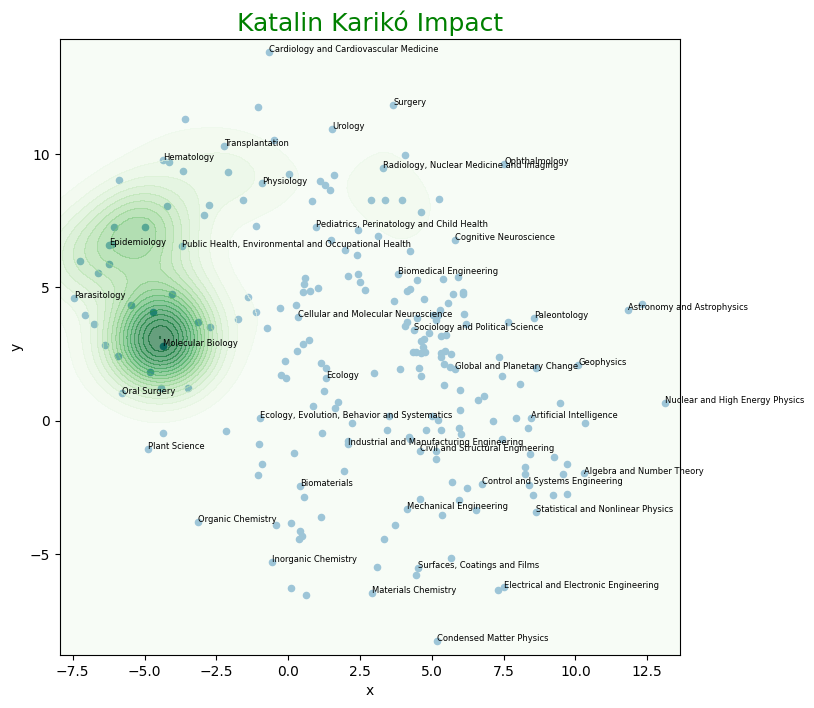

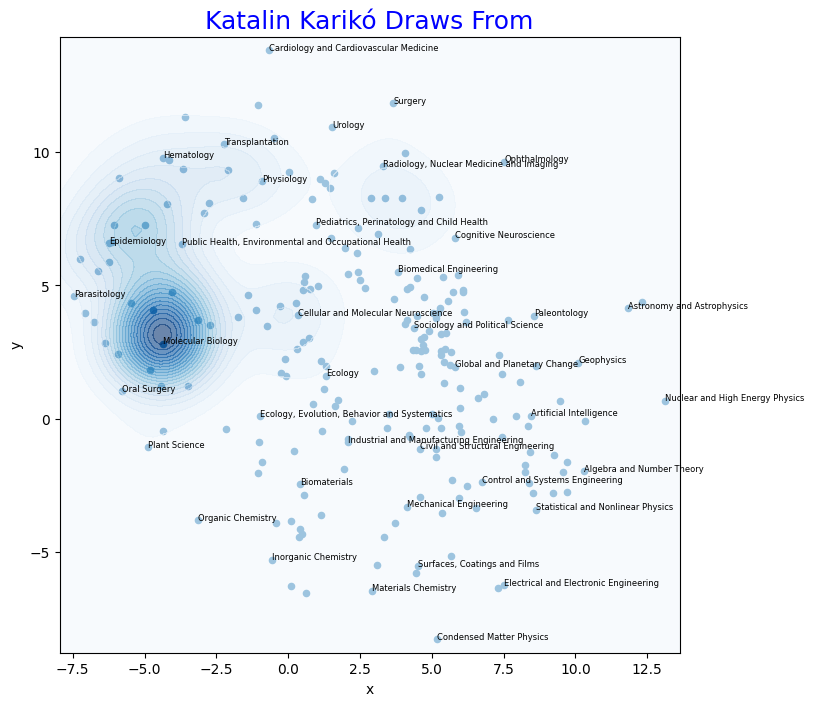

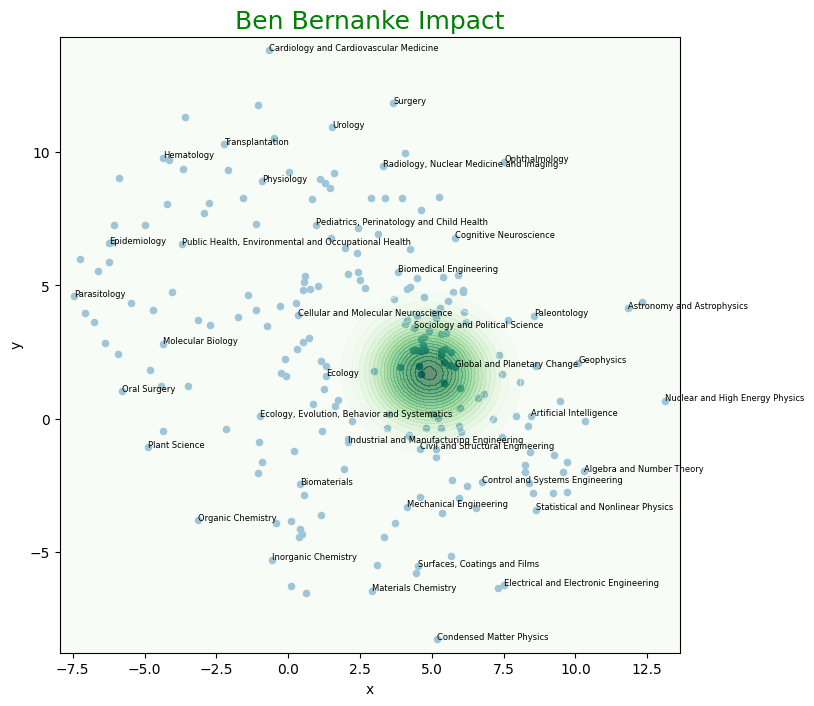

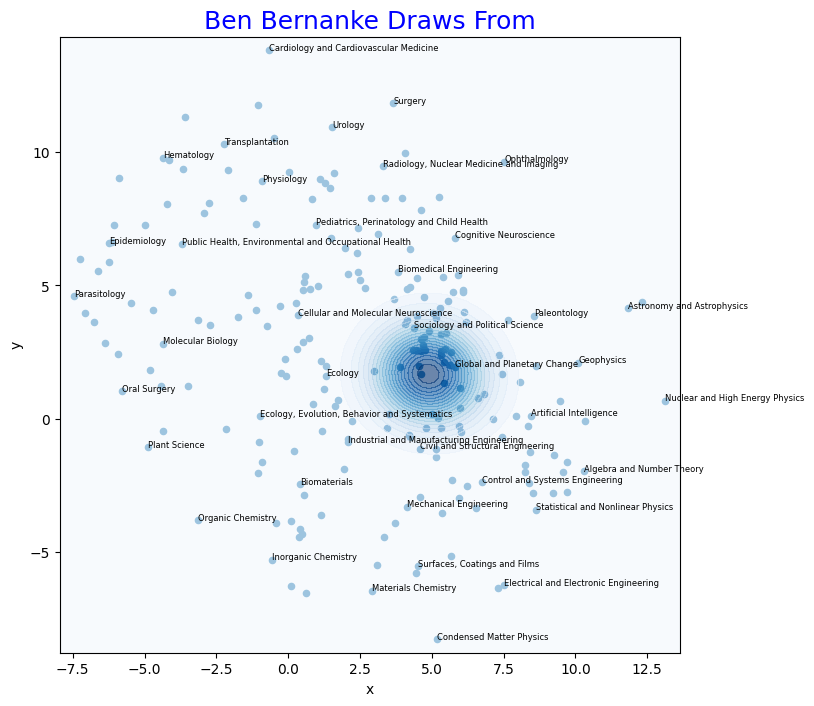

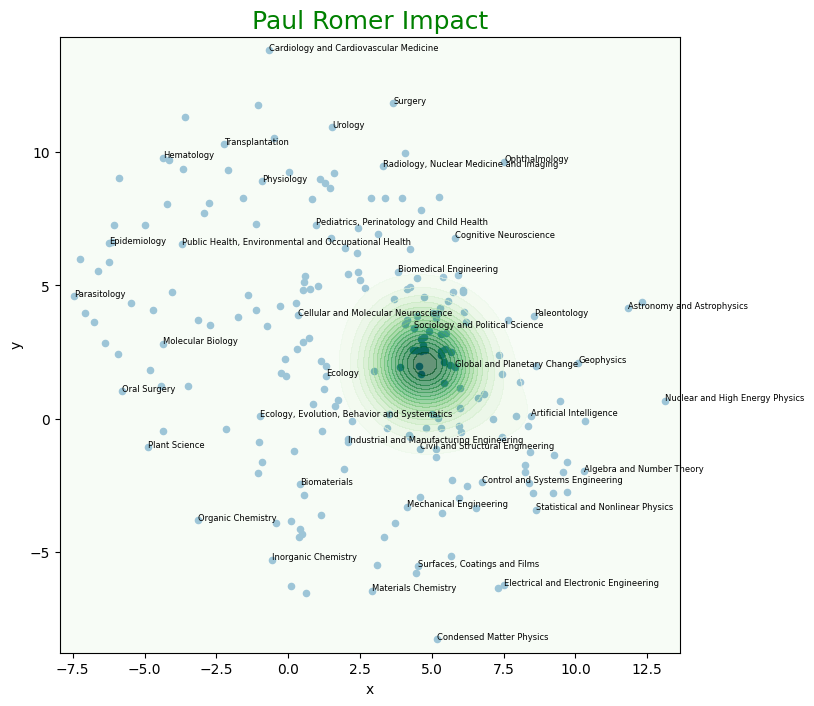

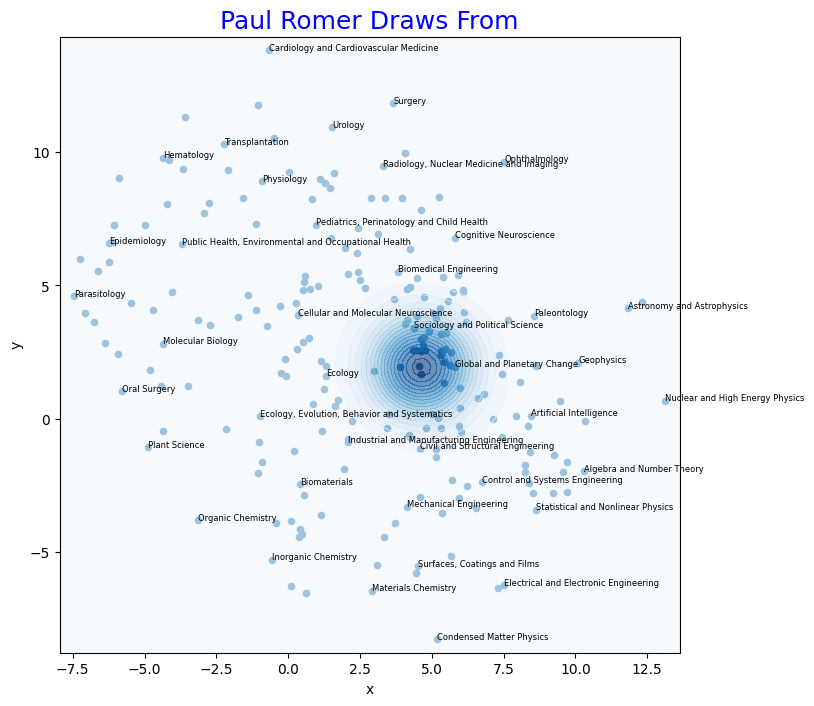

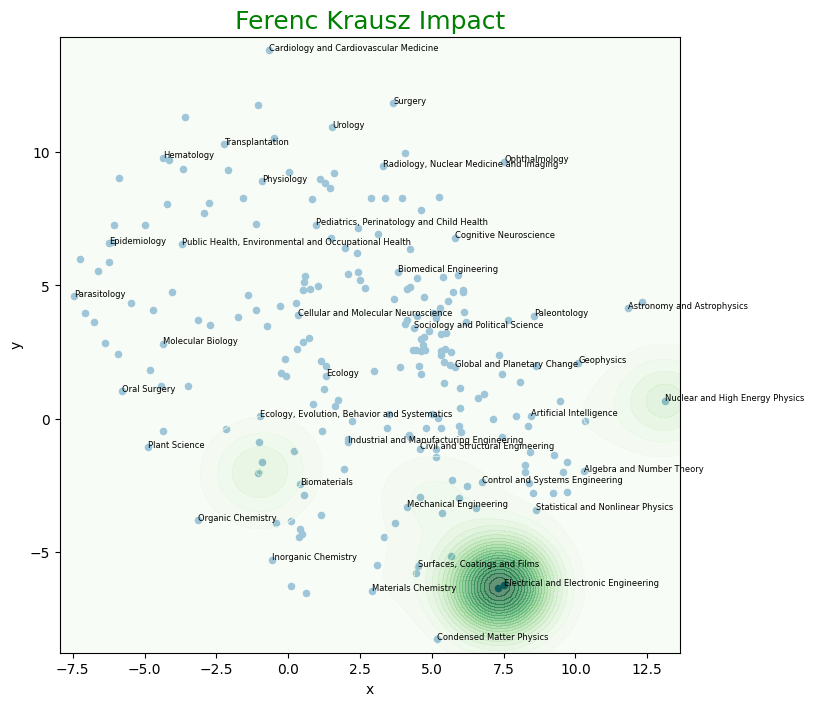

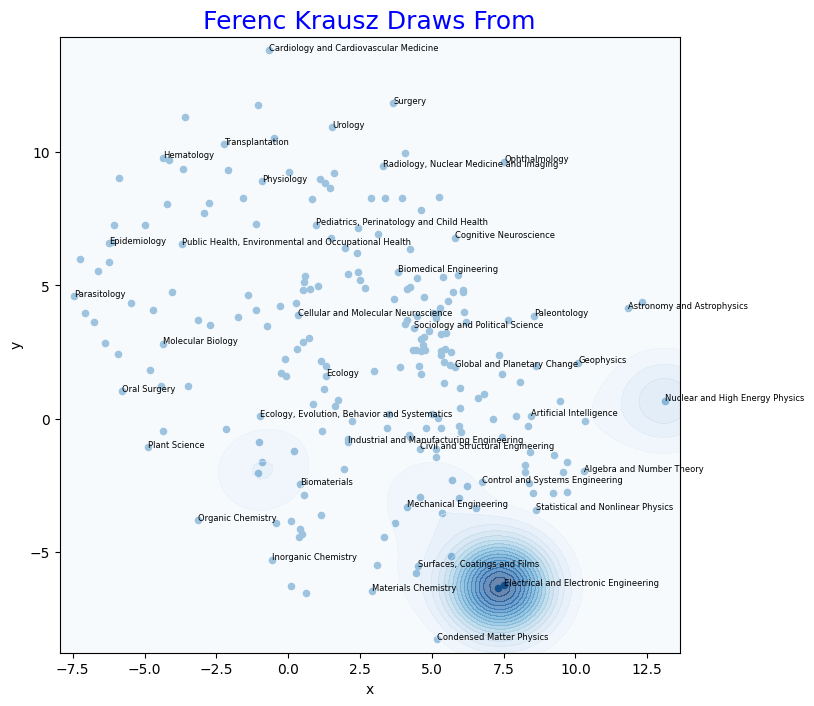

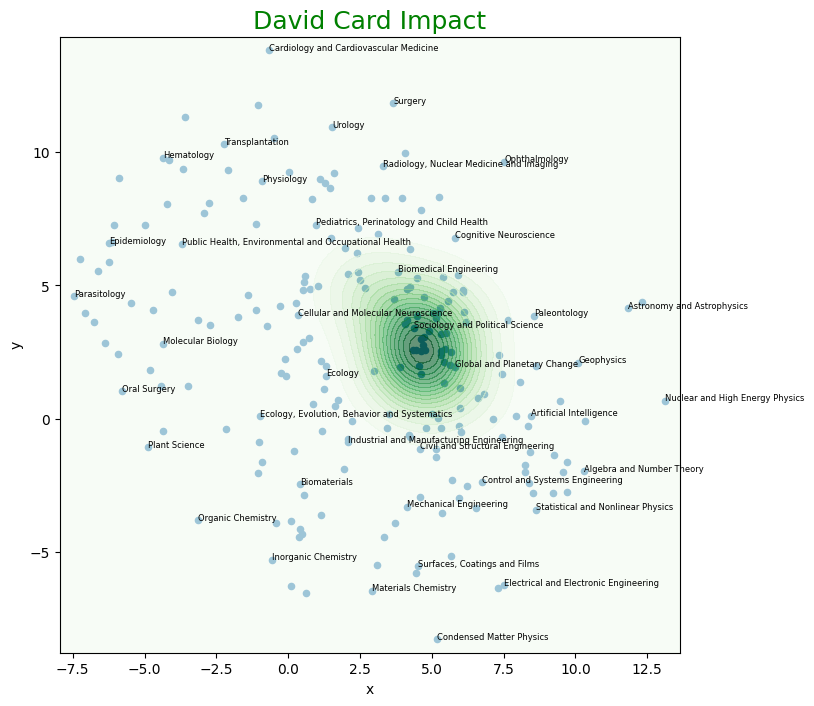

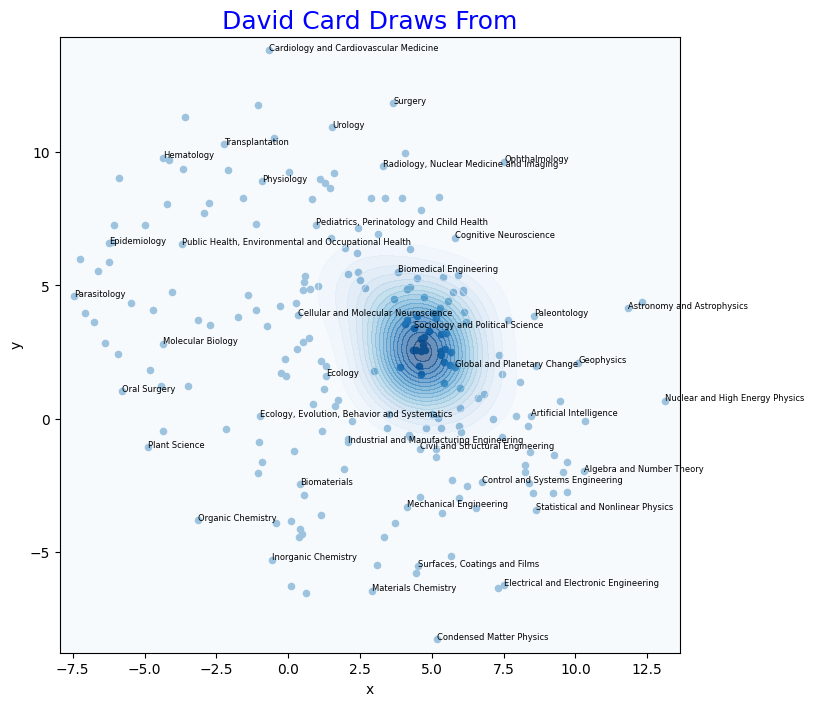

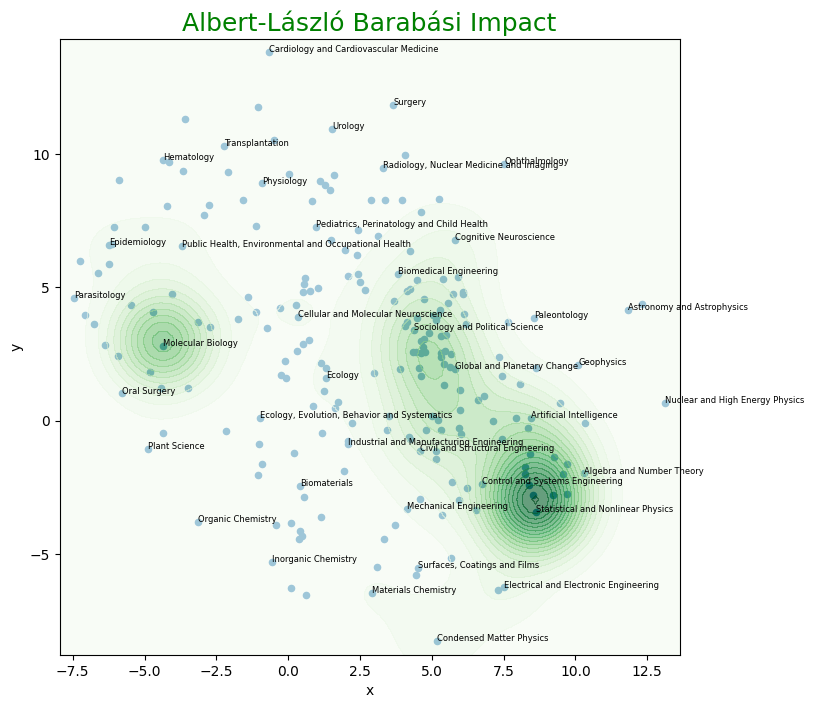

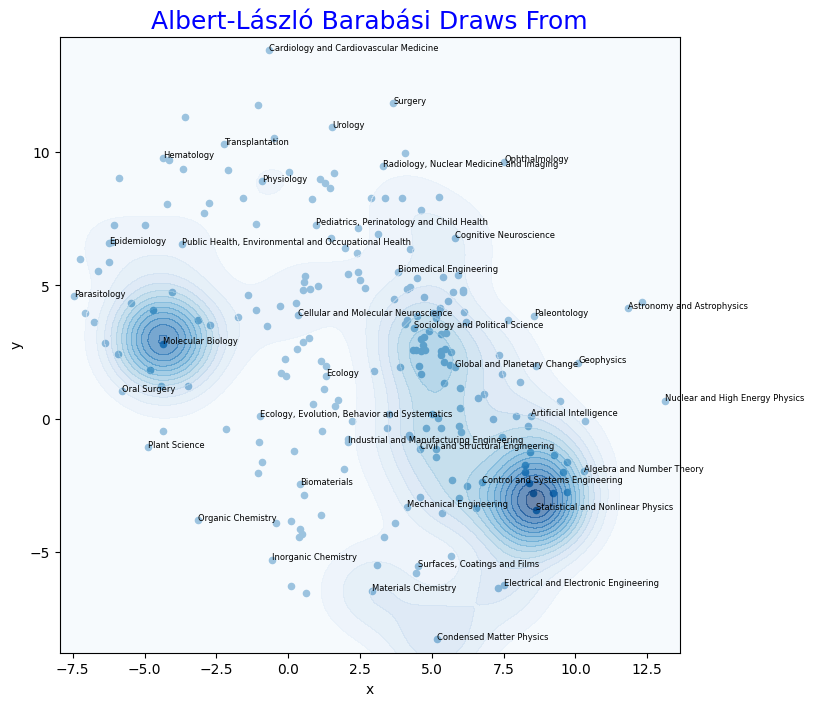

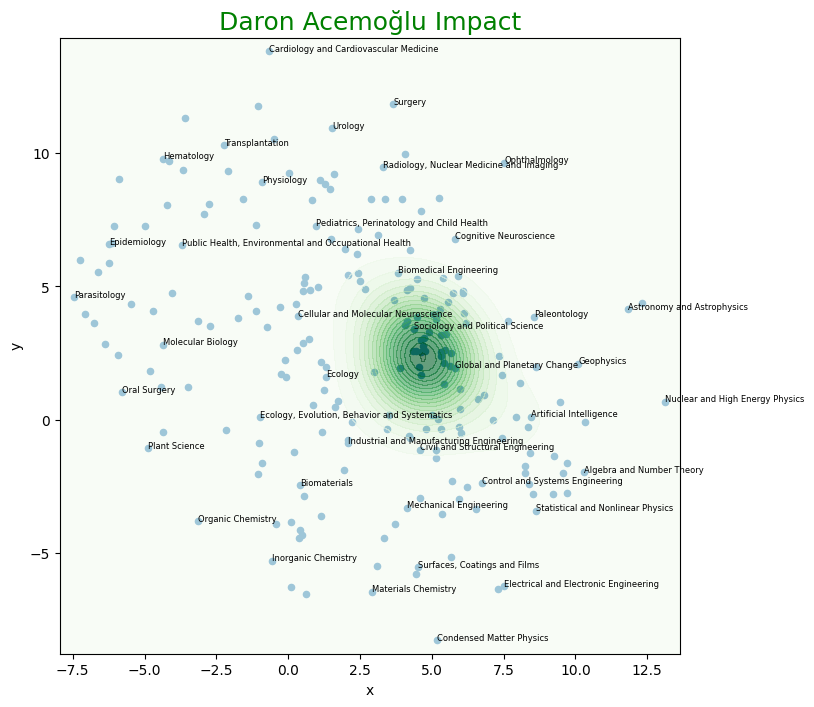

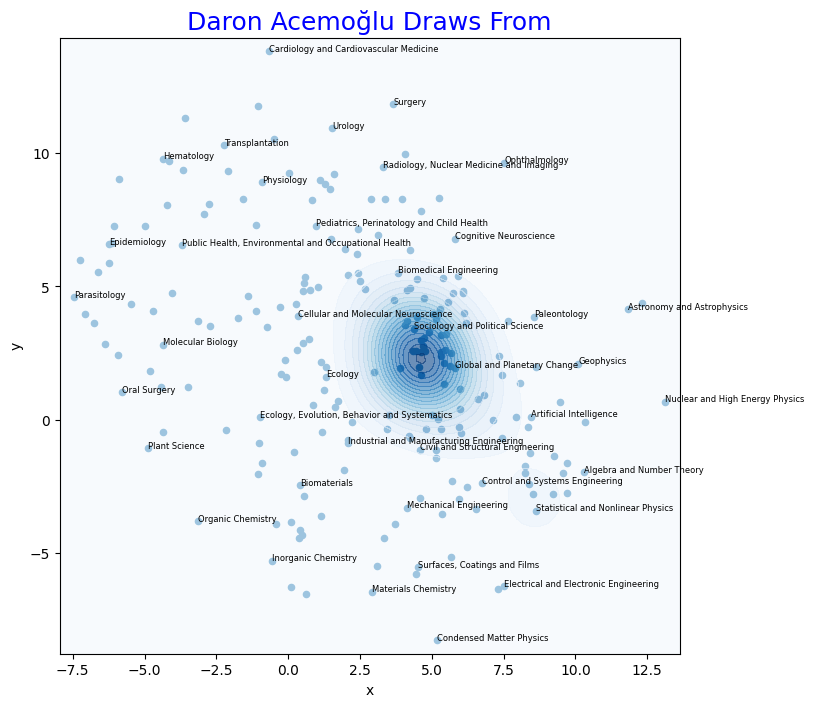

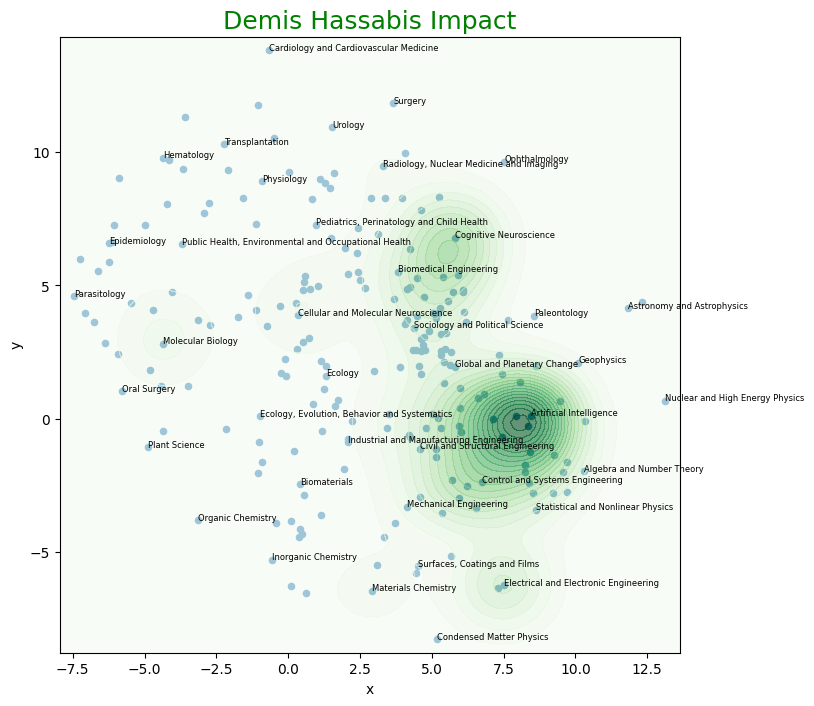

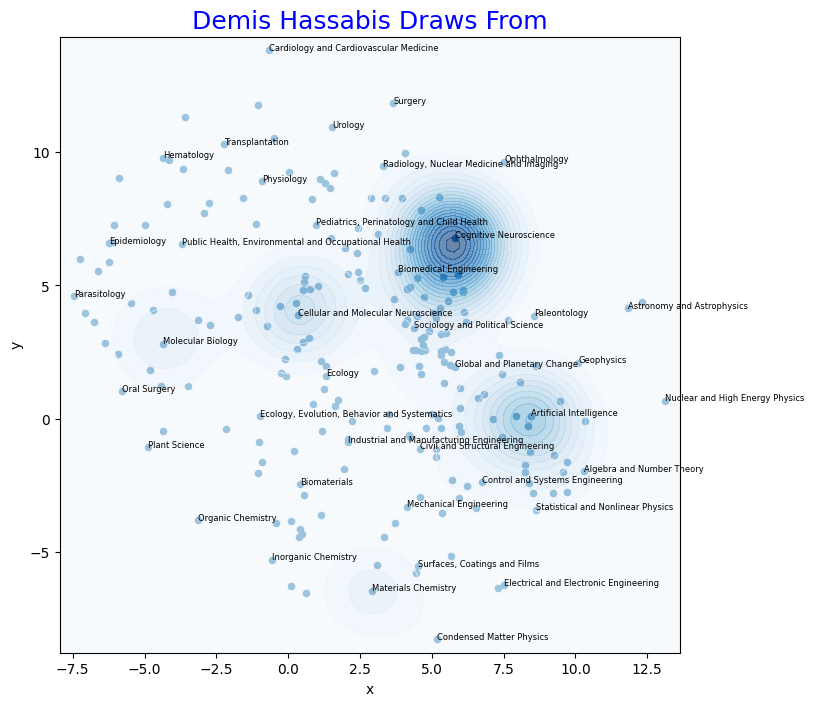

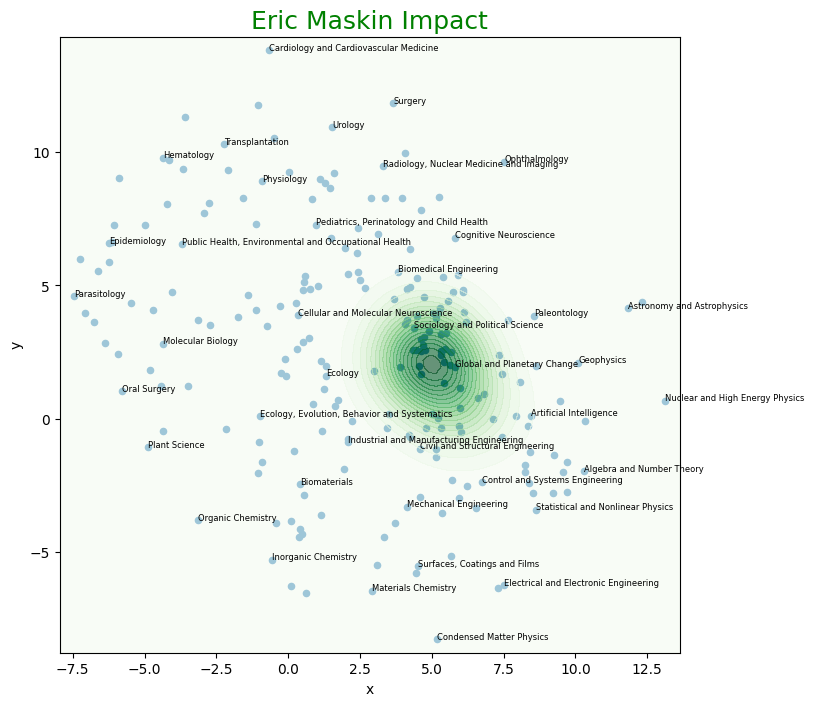

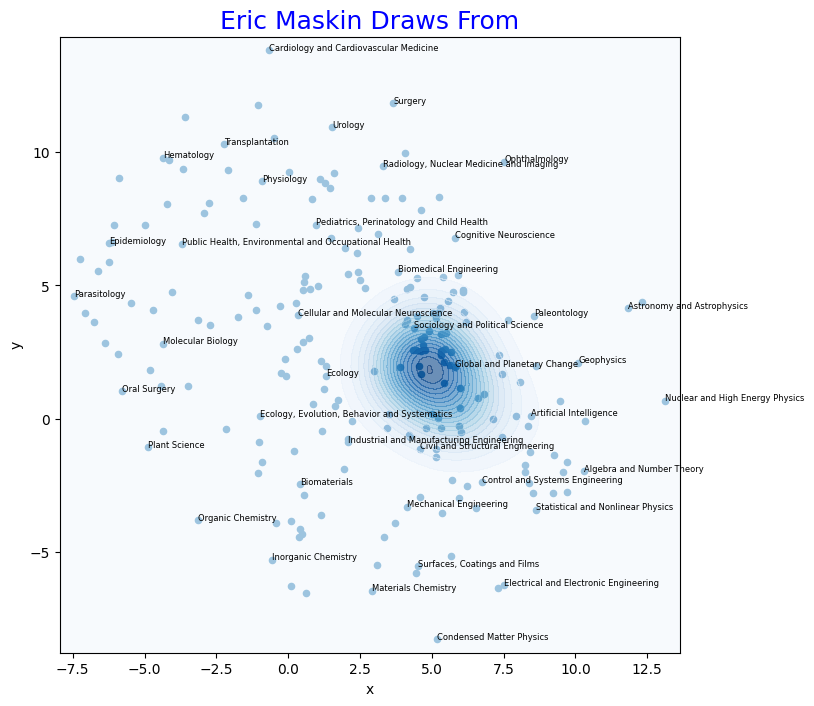

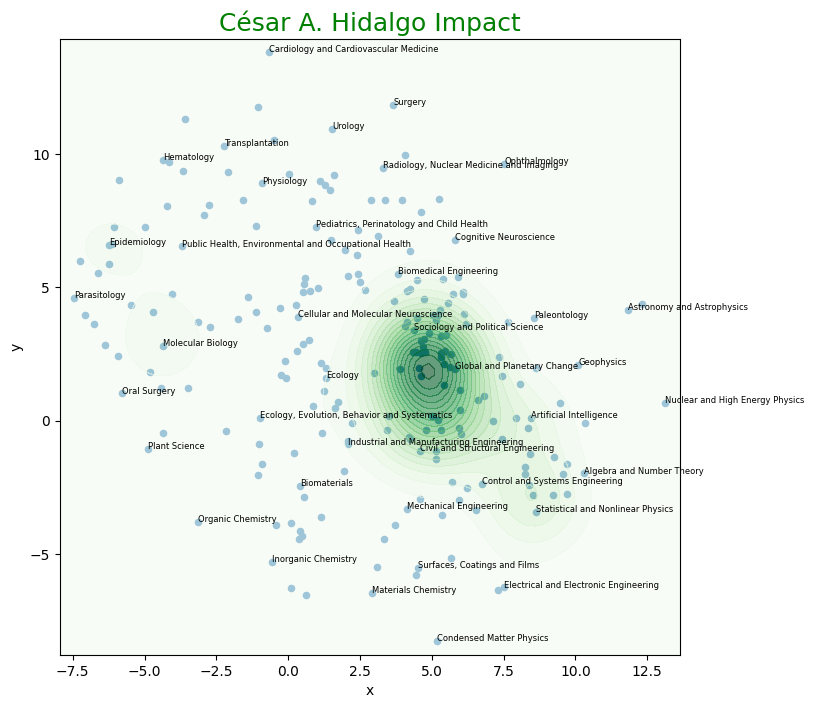

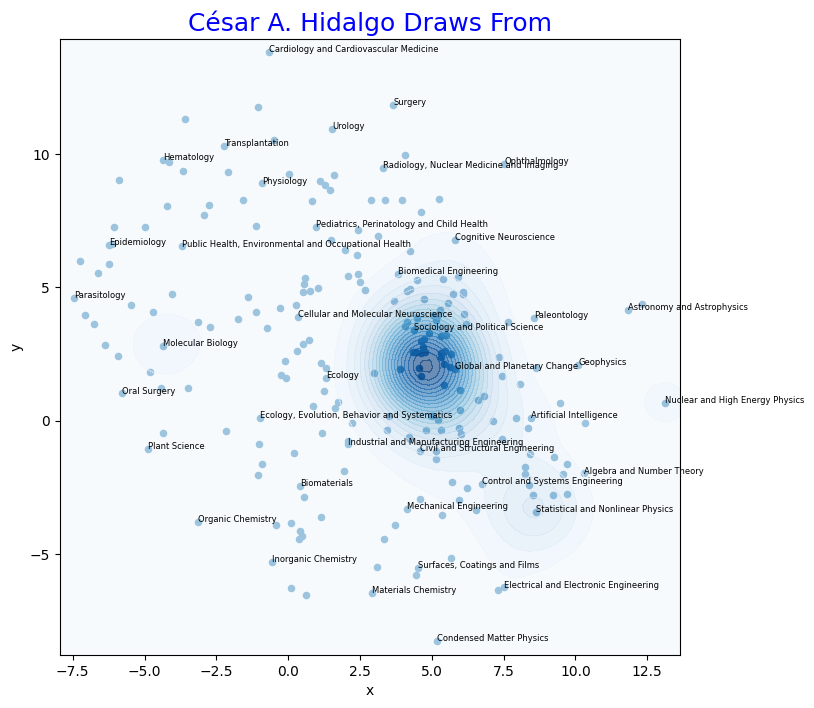

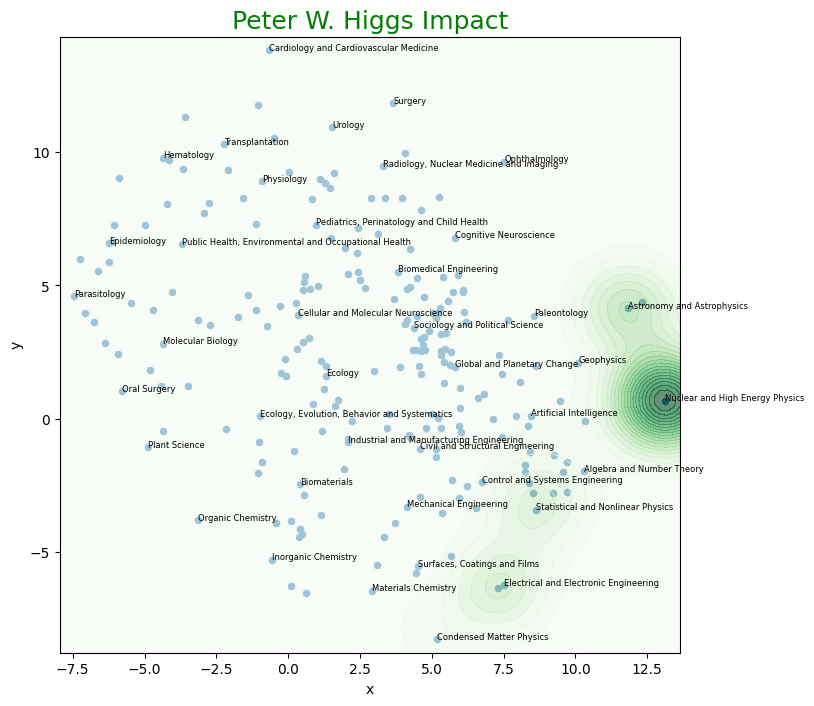

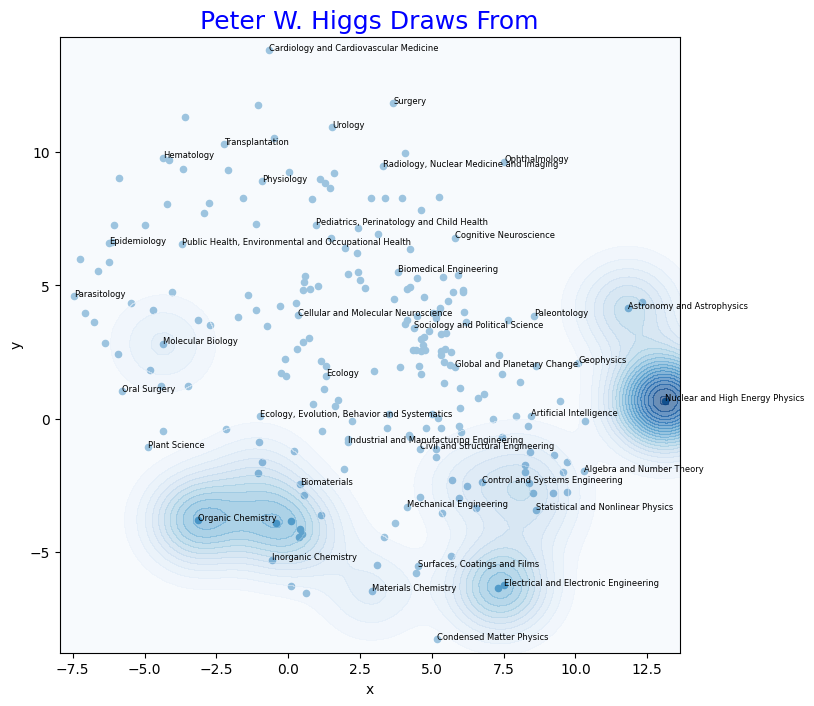

In [438]:
for i in range(len(exss)):
    for cs in [True, False]:b
        viz_blob(i, cs, (8, 8), 6)

In [ ]:
ax.a

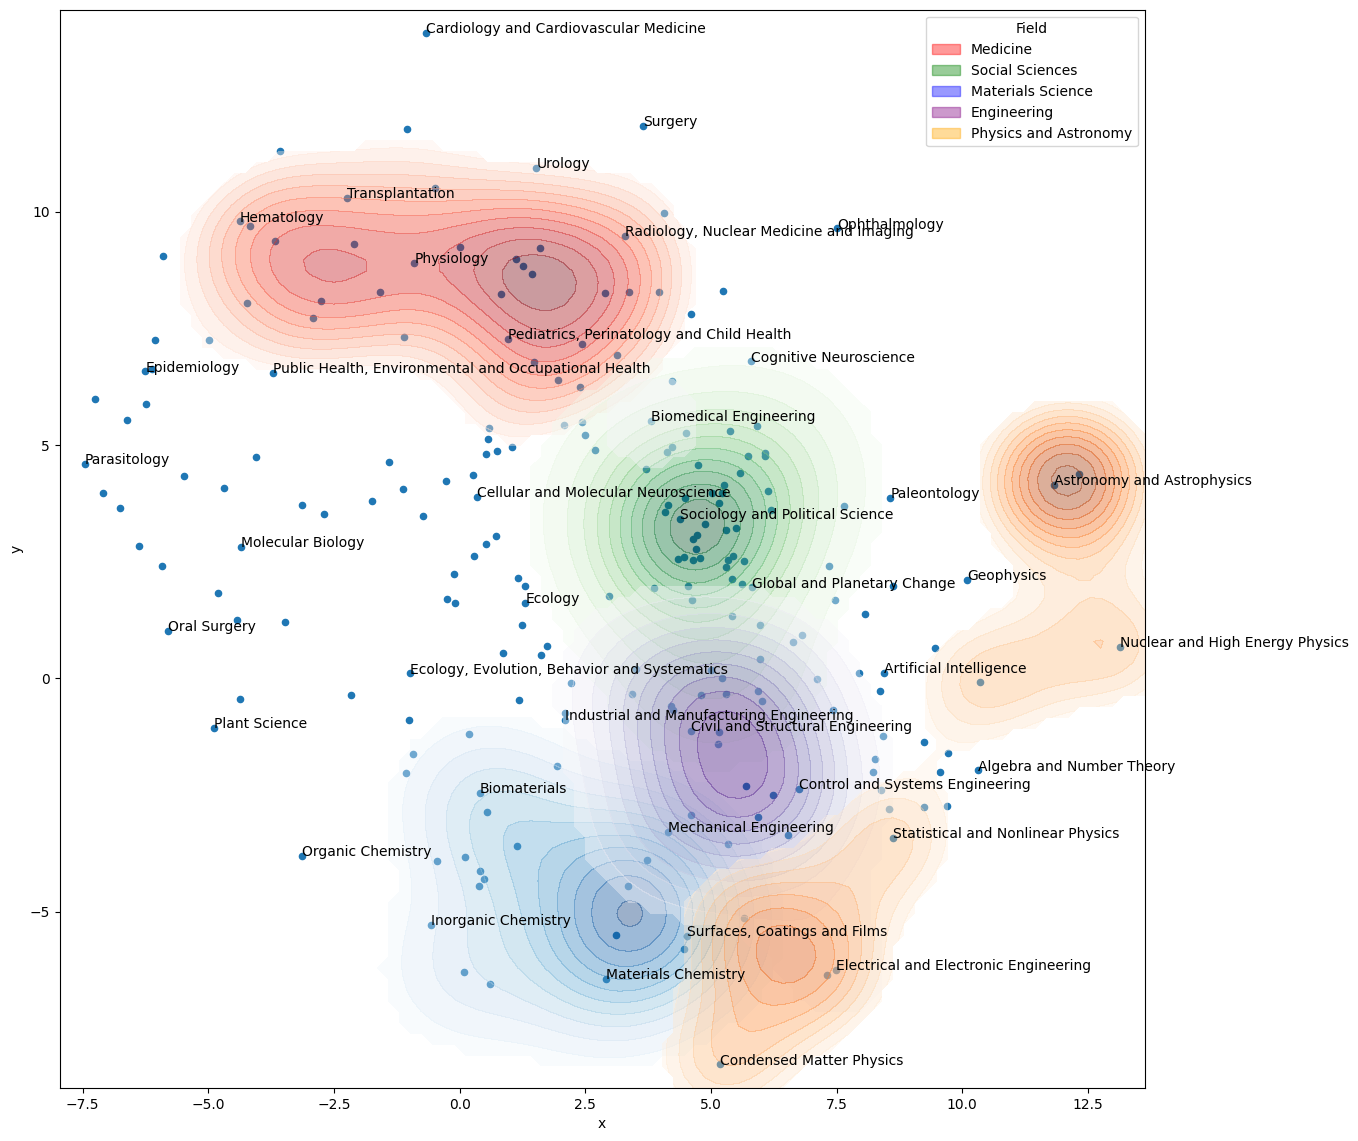

In [430]:
ax = sf_coords.plot.scatter(x=0, y=1, figsize=(14, 14))
annotate_ax(ax)

legend_handles = []
for (gid, gdf), fcolor in zip(
    sf_coords.reset_index(drop=True)
    .sample(frac=1, random_state=742)
    .groupby("field", sort=False),
    ["red", "green", "blue", "purple", "orange"],
):
    sampled_coords = embedded[gdf.index, :]
    kde = KernelDensity(bandwidth=1.3).fit(sampled_coords)
    z = np.exp(kde.score_samples(positions)).reshape(x.shape)
    threshold = 0.01
    threshold = np.quantile(z, 0.9)
    z_masked = np.ma.masked_less(z, threshold)
    contour = ax.contourf(
        x, y, z_masked, levels=10, cmap=fcolor.title() + "s", alpha=0.4
    )
    patch = Patch(color=fcolor, label=gid, alpha=0.4)
    legend_handles.append(patch)

ax.legend(handles=legend_handles, title="Field")
plt.show()

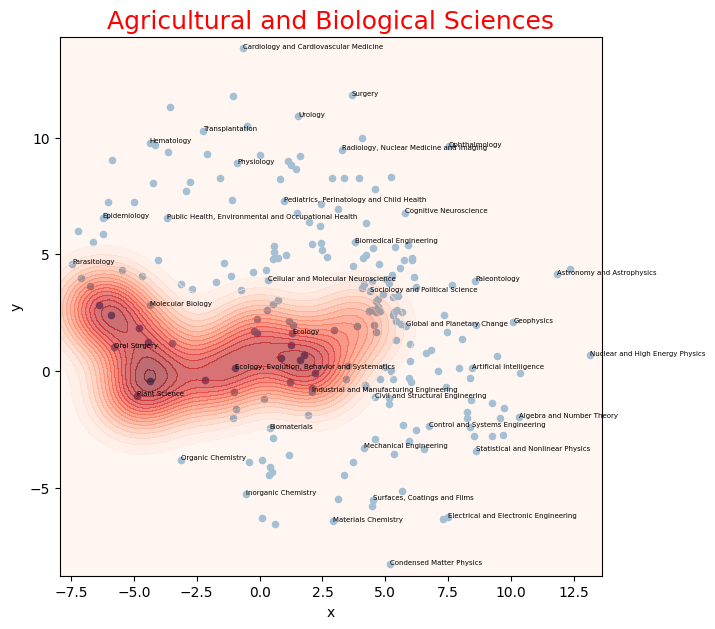

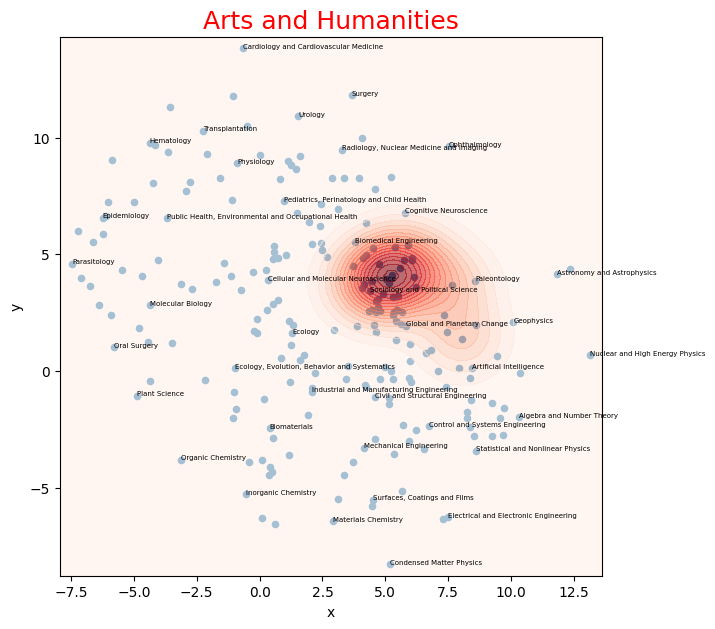

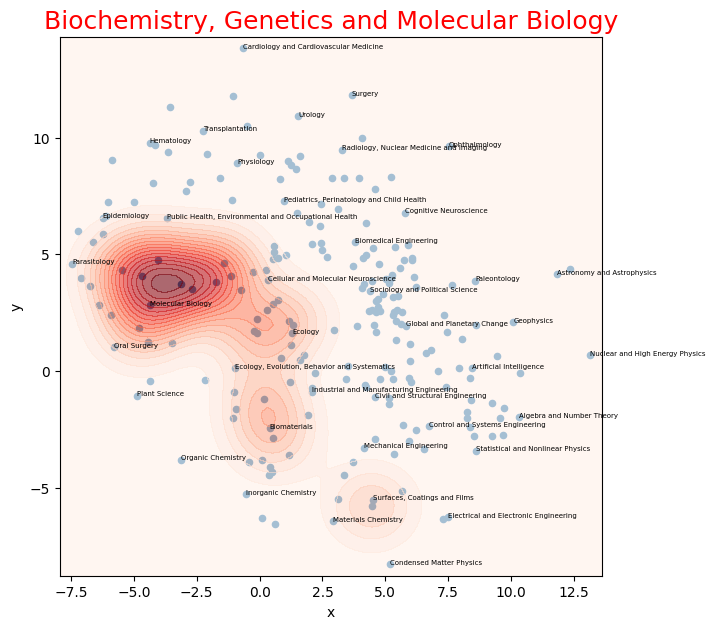

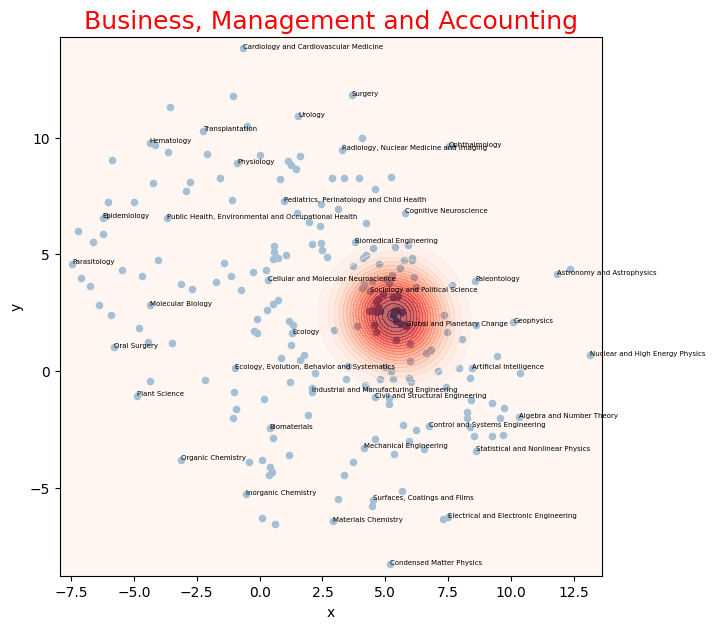

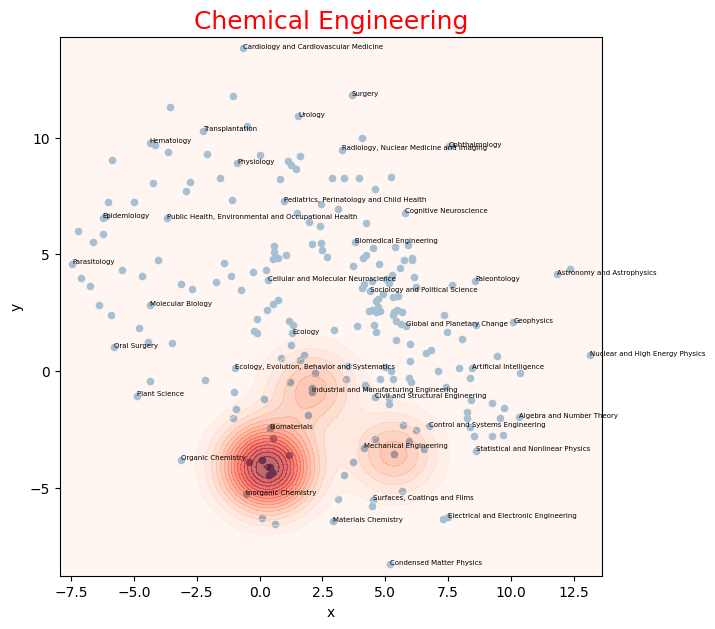

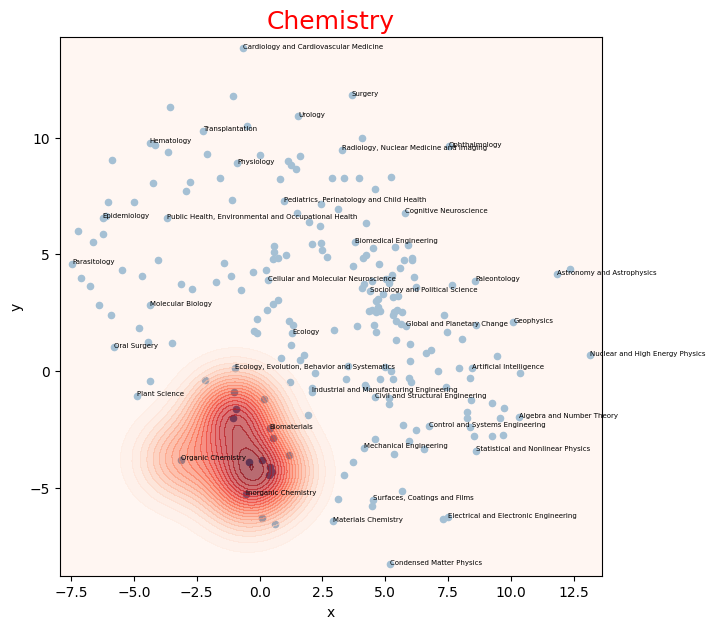

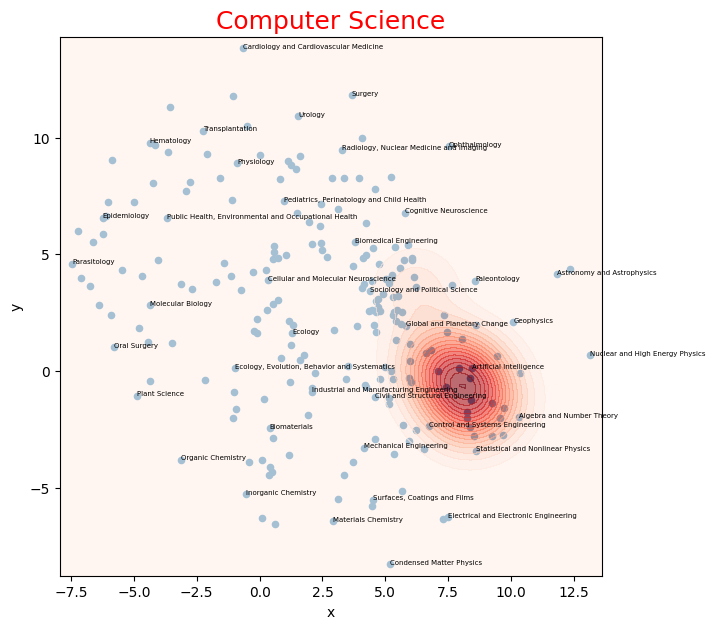

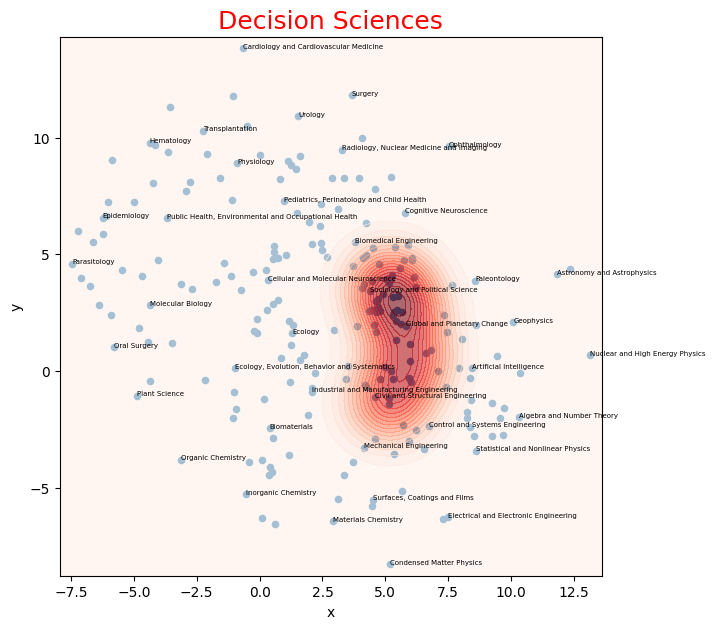

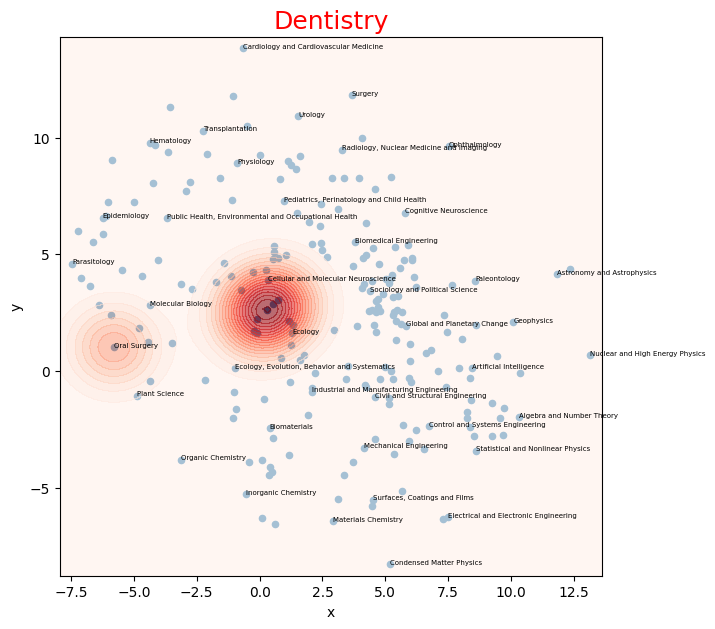

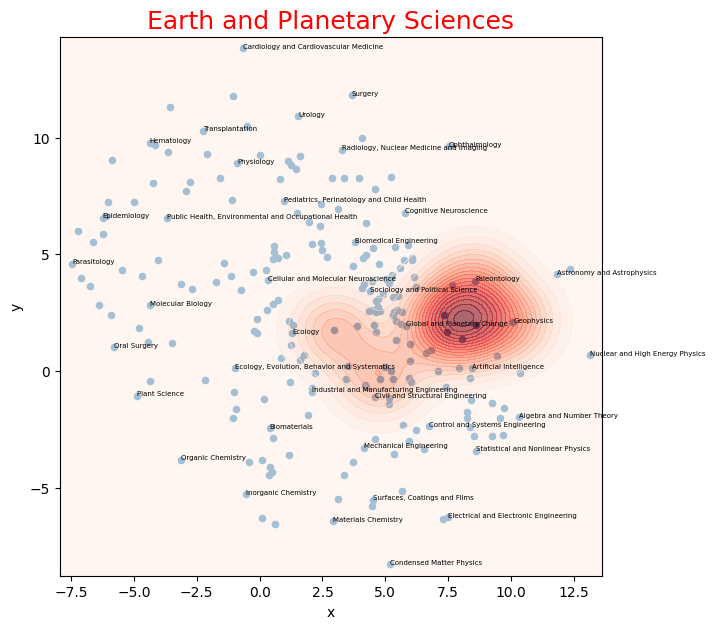

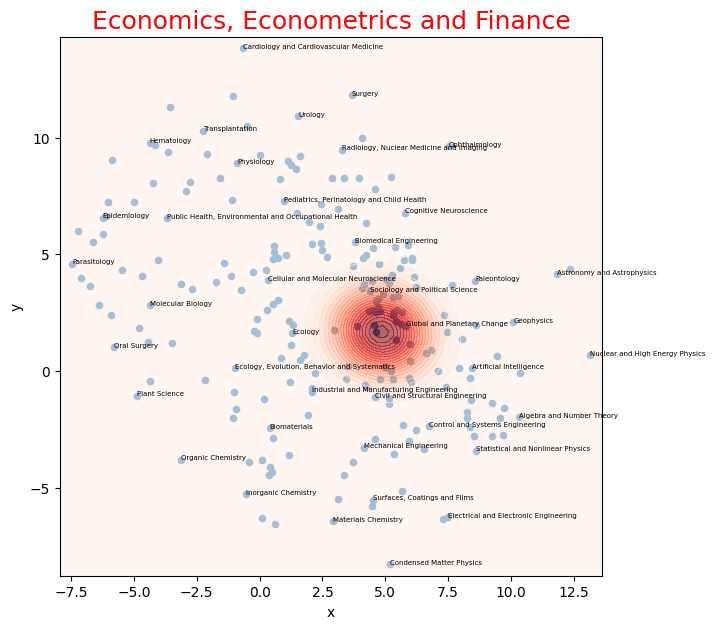

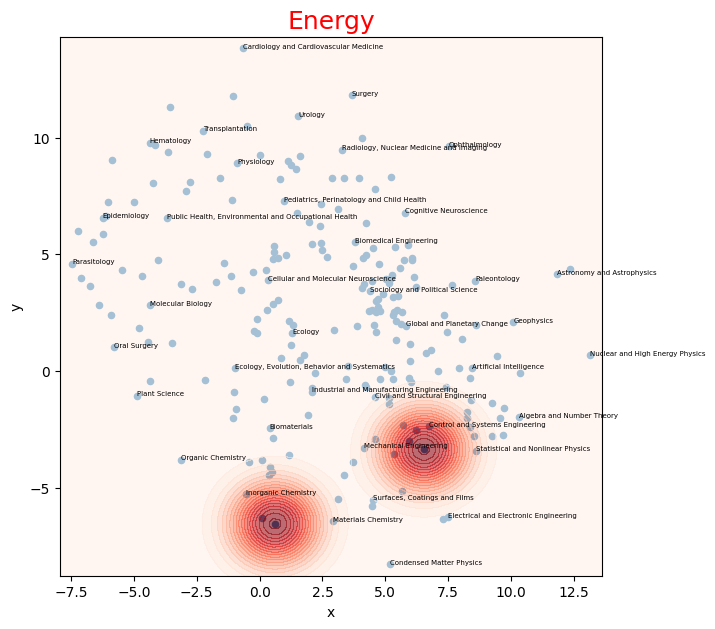

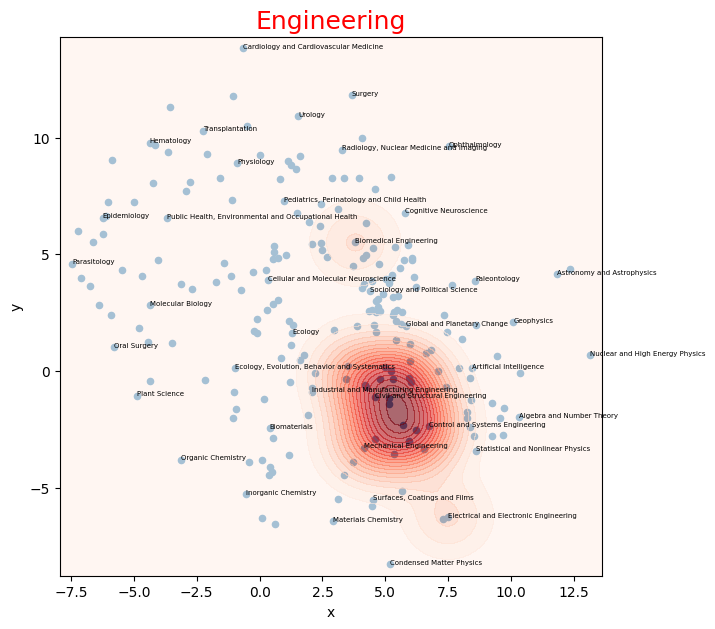

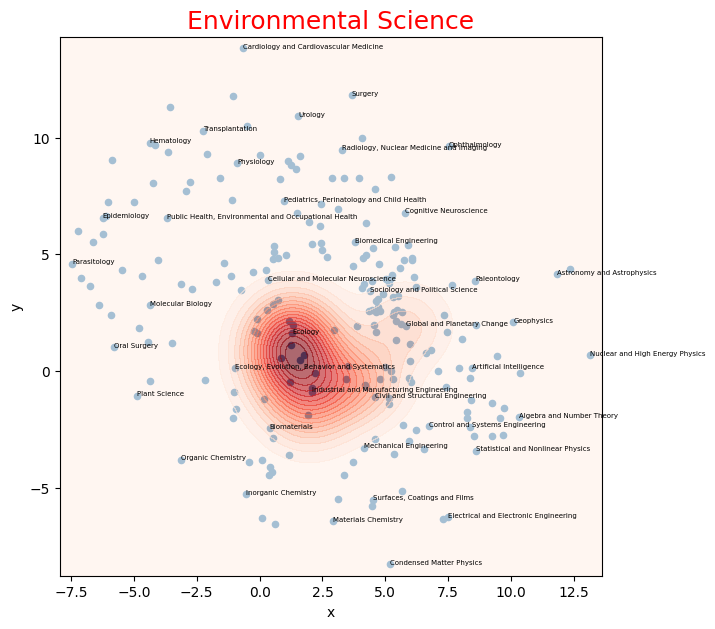

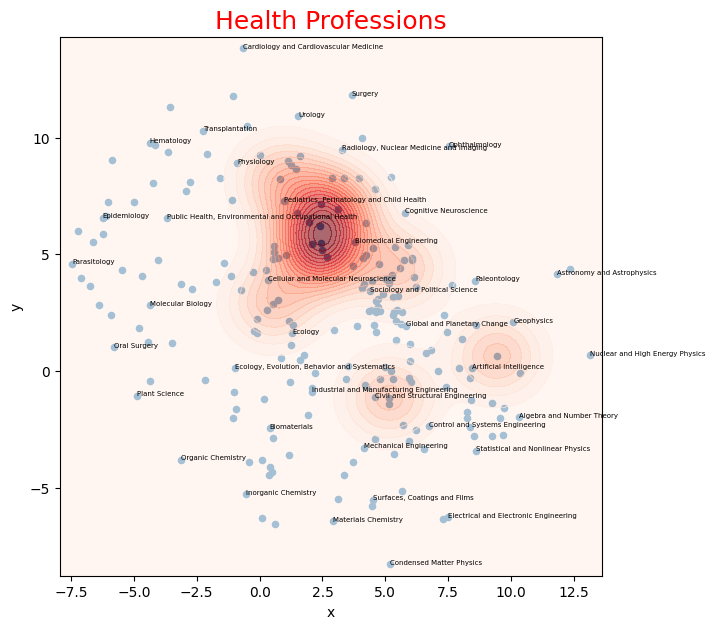

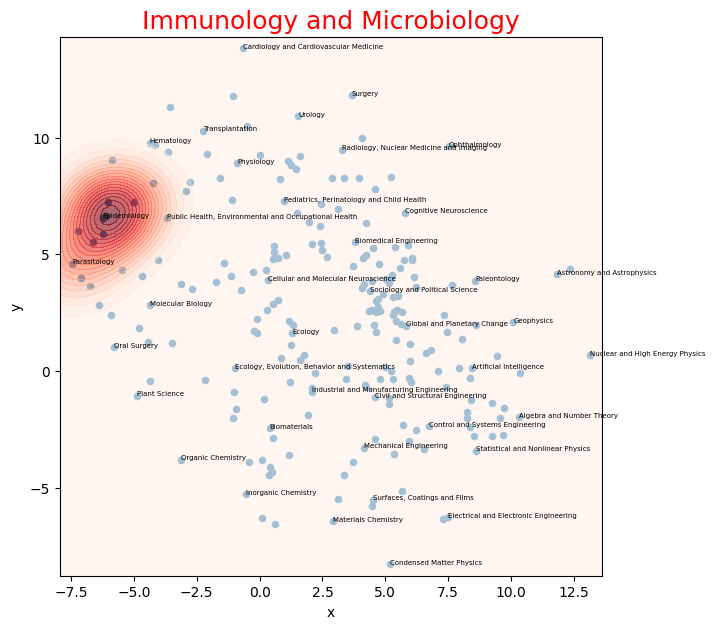

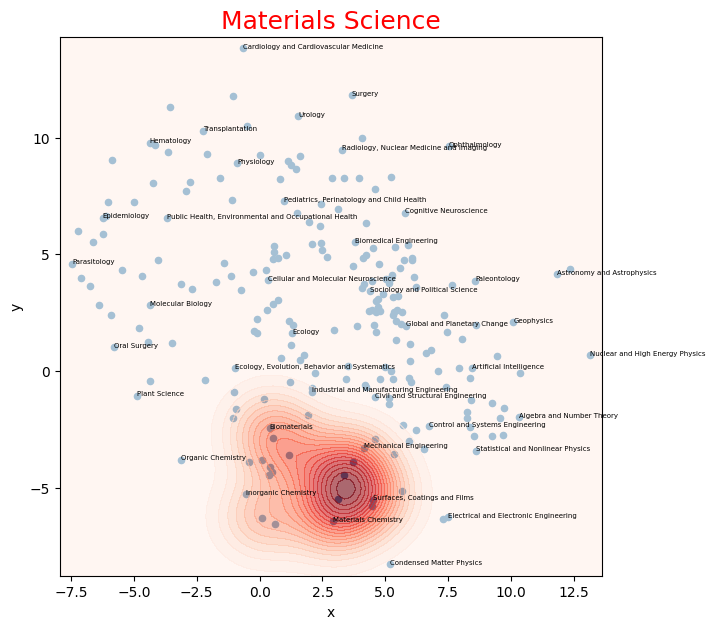

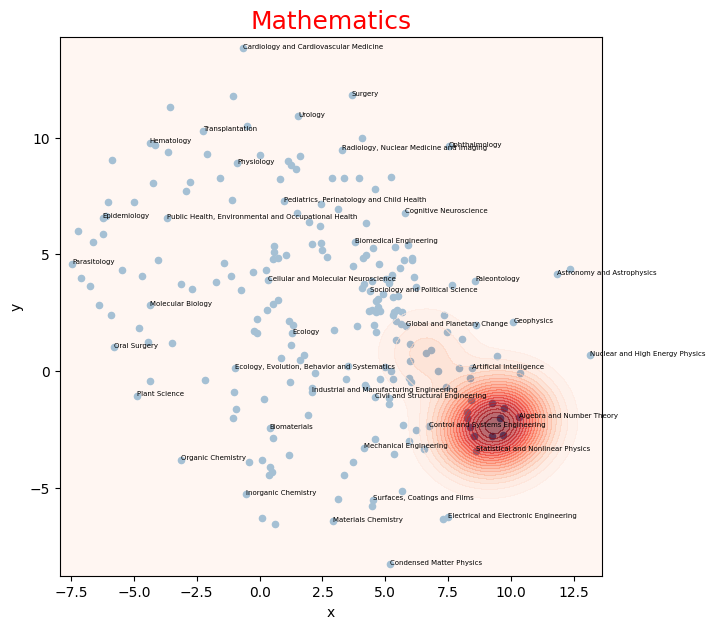

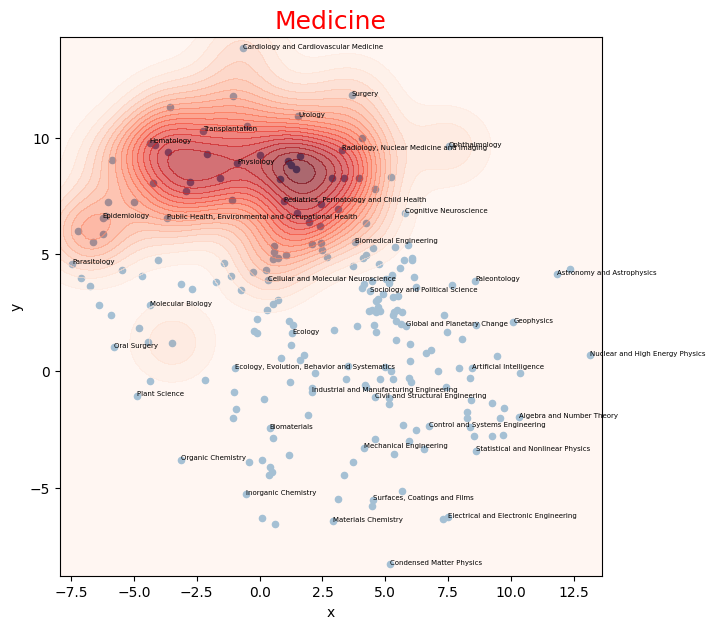

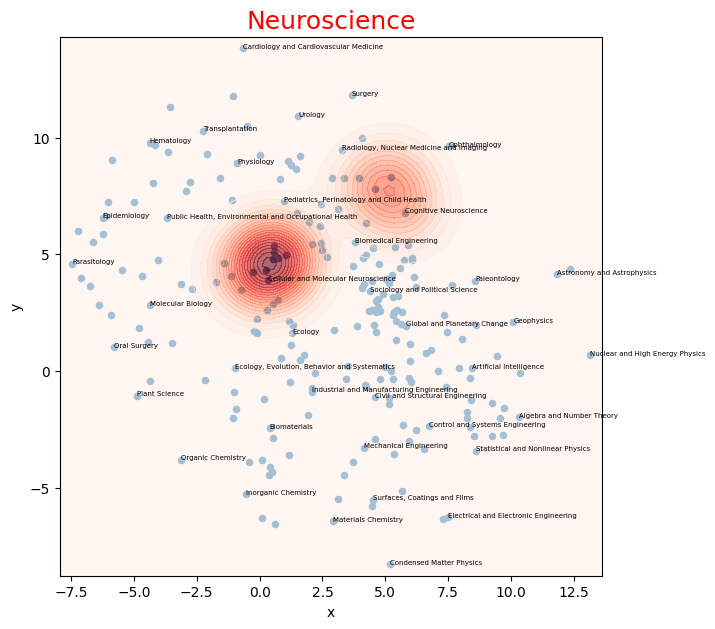

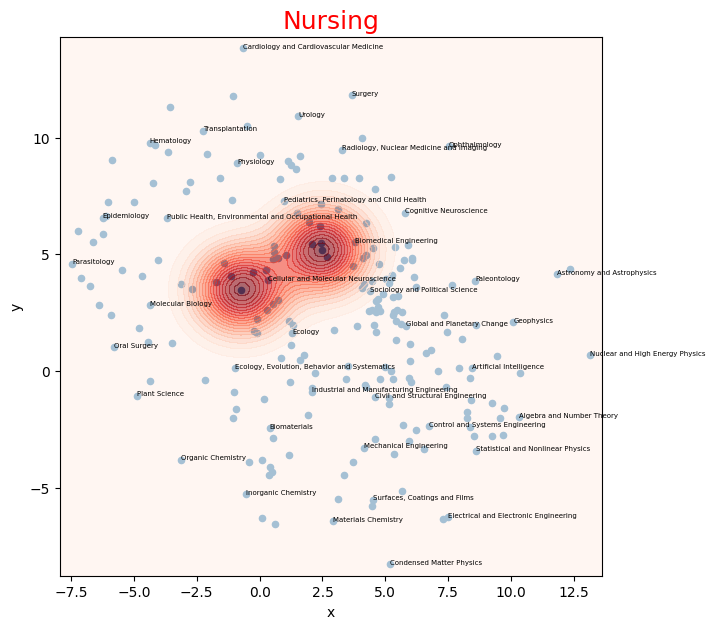

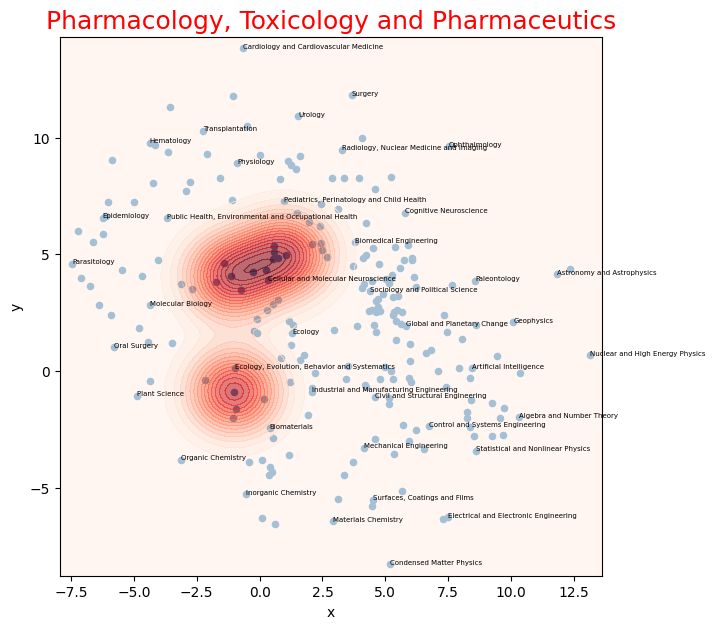

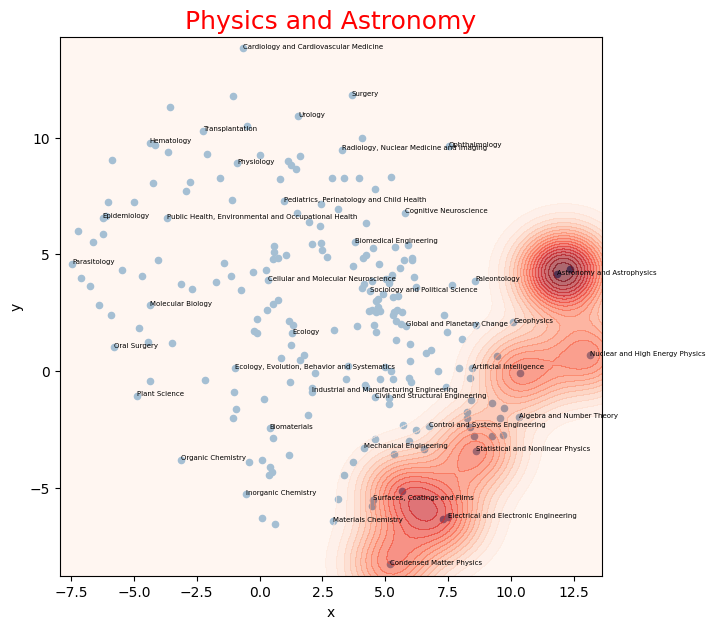

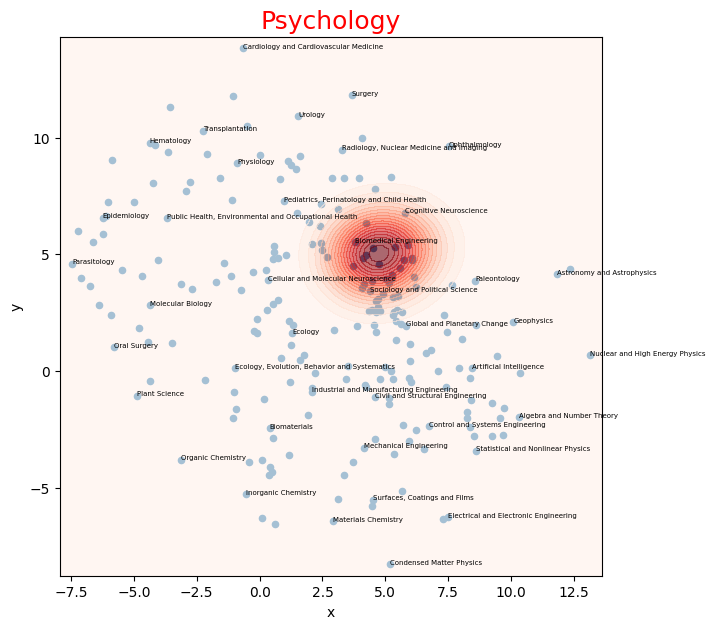

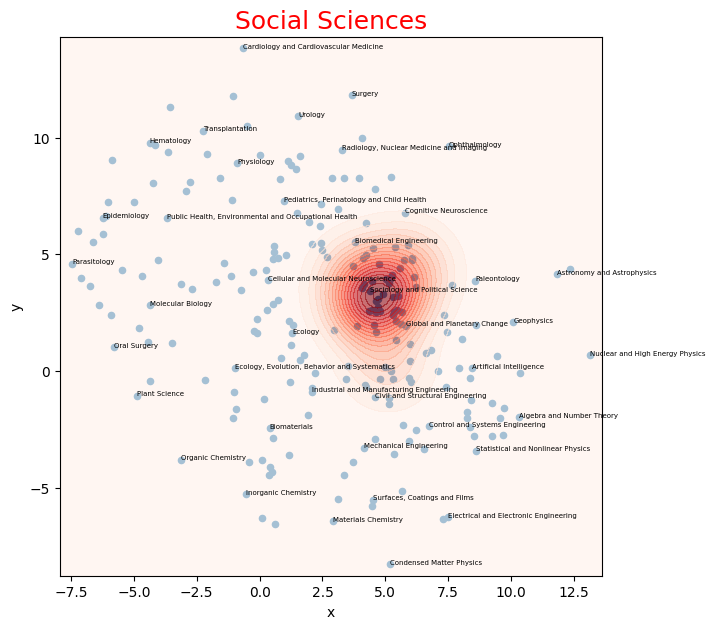

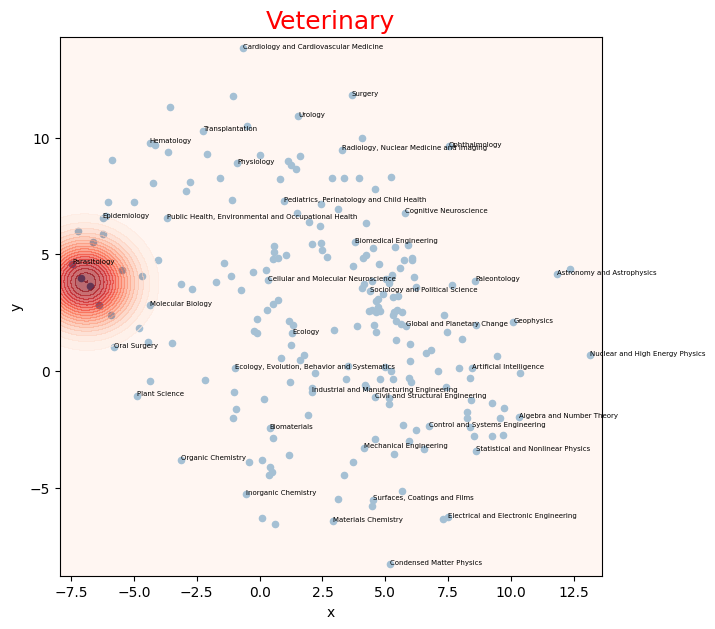

In [439]:
for gid, gdf in sf_coords.reset_index(drop=True).groupby("field"):
    ax = sf_coords.plot.scatter(x=0, y=1, figsize=(7, 7))
    annotate_ax(ax, fontsize=5)
    sampled_coords = embedded[gdf.index, :]
    kde = KernelDensity(bandwidth=bw).fit(sampled_coords)
    z = np.exp(kde.score_samples(positions)).reshape(x.shape)
    ax.set_title(gid, fontdict={"fontsize": 18, "color": "red"})
    contour = ax.contourf(x, y, z, levels=20, cmap="Reds", alpha=0.6)
    plt.show()

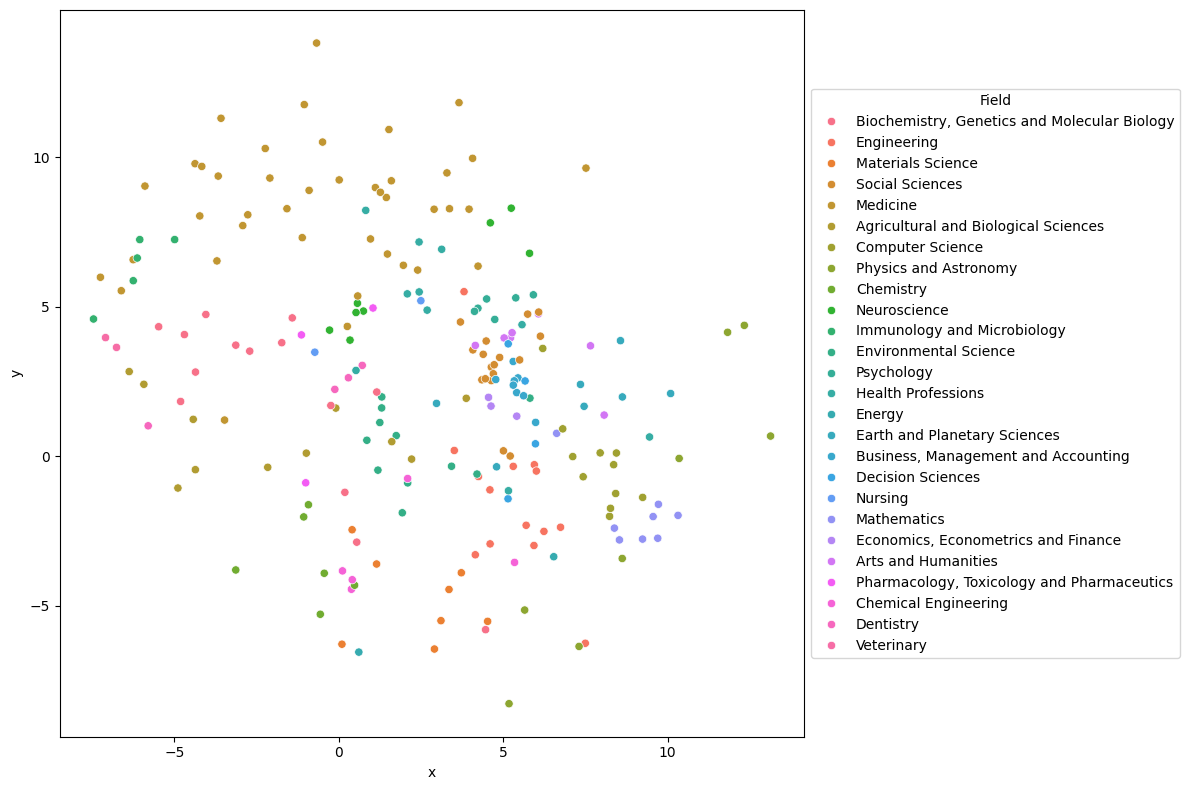

In [260]:
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=sf_coords, x="x", y="y", hue="field")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Field")
plt.tight_layout()
plt.show()